In [1]:
%%writefile requirements.txt
optuna==3.6.1
optuna-integration==3.6.0
scikit-learn==1.5.0
scipy==1.13.1
seaborn==0.13.2
matplotlib==3.9.0
lime==0.2.0.1
shap==0.45.0
opencv-python-headless==4.10.0.84
pandas==2.2.2

Overwriting requirements.txt


# Setup e Importações

In [2]:
# ── Instala dependências com versões fixadas (reprodutibilidade entre sessões Kaggle) ──
!pip install -q -r requirements.txt

import os
import gc
import time
import json
import joblib
import pandas as pd
import numpy as np
import tensorflow as tf
import optuna
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.metrics import f1_score, classification_report

from tensorflow.keras.optimizers import Adam, RMSprop, SGD, AdamW
from tensorflow.keras import regularizers
import tensorflow.keras.backend as K

print(f"TensorFlow: {tf.__version__} | Optuna: {optuna.__version__}")

# ── Reprodutibilidade ──────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Seeds fixados: SEED={SEED}")

# ── Configuração de Datasets ────────────────────────────────────────────────────
# Ativados para a Avaliação Cruzada (Dataset × Modelo) prevista na metodologia (BRACOL,
# RoCoLe e newdataset). BRACOL é tratado como já dividido em train/val/test (mesma
# suposição feita para newdataset) -- confira o caminho real no painel Input do Kaggle
# antes de rodar. RoCoLe NÃO vem pré-dividido, por isso aponta para uma pasta em
# /kaggle/working; a célula "Preparação do RoCoLe" logo abaixo faz o split 70/15/15
# automaticamente na primeira execução (mesma lógica usada no transformers.ipynb, só que
# gravando a pasta "val" em vez de "validation", convenção deste notebook Keras).
DATASETS = {
    'bracol': {
        'train':     '/kaggle/input/newdataset/new_dataset/train',
        'val':       '/kaggle/input/newdataset/new_dataset/val',
        'test':      '/kaggle/input/newdataset/new_dataset/test',
        'n_classes': 5,   # Ferrugem, Bicho-Mineiro, Cercosporiose, Phoma e Saudável (Tabela 1 da proposta)
    },
    'rocole': {
        'train':     '/kaggle/working/datasets/rocole/train',
        'val':       '/kaggle/working/datasets/rocole/val',
        'test':      '/kaggle/working/datasets/rocole/test',
        'n_classes': 3,   # Ferrugem, Ácaro Vermelho e Saudável (Tabela 1 da proposta)
    },
}

DATASET_ATIVO = 'bracol'

# ── Configuração de Backbones ──────────────────────────────────────────────
# Critério de seleção: arquiteturas leves/mobile-friendly (MobileNetV3, EfficientNetV2B0,
# NASNetMobile) para comparar contra o MobileNetV2 já validado na IC, mais dois baselines
# "pesados" (ResNet50V2, DenseNet121) só como contraste de acurácia x latência — não são
# candidatos a embarcar no app. ft_range é o intervalo de busca do Optuna para a camada de
# corte do fine-tuning; se exceder o nº real de camadas do backbone não há erro, o Optuna
# simplesmente pode escolher "descongelar tudo".
BACKBONES = {
    'MobileNetV2': {
        'builder':    tf.keras.applications.MobileNetV2,
        'preprocess': tf.keras.applications.mobilenet_v2.preprocess_input,
        'ft_range':   (20, 140),
    },
    'MobileNetV3Small': {
        'builder':    tf.keras.applications.MobileNetV3Small,
        'preprocess': tf.keras.applications.mobilenet_v3.preprocess_input,
        'ft_range':   (20, 200),
    },
    'MobileNetV3Large': {
        'builder':    tf.keras.applications.MobileNetV3Large,
        'preprocess': tf.keras.applications.mobilenet_v3.preprocess_input,
        'ft_range':   (20, 260),
    },
    'EfficientNetV2B0': {
        'builder':    tf.keras.applications.EfficientNetV2B0,
        'preprocess': tf.keras.applications.efficientnet_v2.preprocess_input,
        'ft_range':   (20, 260),
    },
    'NASNetMobile': {
        'builder':    tf.keras.applications.NASNetMobile,
        'preprocess': tf.keras.applications.nasnet.preprocess_input,
        'ft_range':   (20, 760),
    },
    # Baselines "pesados" — apenas para contraste de acurácia x latência, não são
    # candidatos reais a embarcar no app offline. Descomente para incluir na Avaliação
    # Cruzada; deixados fora por padrão para não inflar o tempo de execução do loop.
    # 'ResNet50V2': {
    #     'builder':    tf.keras.applications.ResNet50V2,
    #     'preprocess': tf.keras.applications.resnet_v2.preprocess_input,
    #     'ft_range':   (20, 175),
    # },
    # 'DenseNet121': {
    #     'builder':    tf.keras.applications.DenseNet121,
    #     'preprocess': tf.keras.applications.densenet.preprocess_input,
    #     'ft_range':   (20, 420),
    # },
}

BACKBONE_ATIVO = 'MobileNetV2'

# ── Derivados da configuração ativa ───────────────────────────────────────
N_CLASSES    = DATASETS[DATASET_ATIVO]['n_classes']
NOME_ARQUIVO = f"{BACKBONE_ATIVO}_{DATASET_ATIVO}"

# Cada combinação Modelo × Dataset grava seus artefatos numa pasta própria,
# evitando sobrescrita ao rodar múltiplas combinações em sequência (Avaliação Cruzada).
OUTPUT_DIR = os.path.join('outputs', NOME_ARQUIVO)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Acumula métricas de todas as combinações modelo × dataset
resultados_comparativos = []

print(f"Dataset ativo : {DATASET_ATIVO} ({N_CLASSES} classes)")
print(f"Backbone ativo: {BACKBONE_ATIVO}")
print(f"Prefixo de saída: {NOME_ARQUIVO}")
print(f"Diretório de saída: {OUTPUT_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 3.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.4/93.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 63.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 66.9 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.2/538.2 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 57.3 MB/s eta 0:00:0000:01:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires notebook==6.5.5, but you have notebook 6.5.4 which is incompatible.
pandas-gbq 0.25.0 requires google-api-core<3.0.0dev,>=2.10.2, but you have google-api-core 1.34.1 which is incompatible.
tensorflow-d

# Preparação do RoCoLe (divisão Train/Val/Test)

In [3]:
# O RoCoLe (diferente do newdataset e do BRACOL) não vem pré-dividido em train/val/test --
# precisa ser separado antes do image_dataset_from_directory conseguir ler os splits. Usa
# os nomes de pasta "train"/"val"/"test" (convenção deste notebook Keras) -- no
# transformers.ipynb a mesma preparação grava "validation" em vez de "val", por causa do
# load_dataset("imagefolder") do Hugging Face, que não reconhece "val" como nome de split.
def _localizar_raw_dir_rocole():
    """O caminho exato do RoCoLe dentro de /kaggle/input varia conforme como o dataset foi
    anexado -- às vezes os arquivos ficam direto na raiz (/kaggle/input/rocole/), às vezes
    dentro de uma subpasta extra com o nome do dataset (ex.: RoCoLe-dataset). Em vez de
    fixar um único palpite, tenta os candidatos mais prováveis e usa o primeiro que existir
    e contiver pelo menos 2 subpastas (as classes)."""
    import pathlib
    candidatos = [
        pathlib.Path("/kaggle/input/rocole/RoCoLe-dataset"),
        pathlib.Path("/kaggle/input/datasets/nirmalsankalana/rocole-a-robusta-coffee-leaf-images-datasete"),
        pathlib.Path("/kaggle/input/rocole"),
    ]
    for cand in candidatos:
        if cand.exists() and sum(1 for d in cand.iterdir() if d.is_dir()) >= 2:
            return cand
    raise FileNotFoundError(
        f"Não encontrei a pasta bruta do RoCoLe em nenhum destes caminhos: {candidatos}. "
        "Rode `!find /kaggle/input/rocole -maxdepth 2` numa célula para achar o caminho "
        "real e ajuste ROCOLE_RAW_DIR manualmente."
    )


def preparar_rocole():
    """Divide o RoCoLe bruto em train/val/test (70/15/15) se ainda não foi feito.
    Idempotente: se a pasta de destino já existir, não refaz o split."""
    import pathlib
    import shutil
    from sklearn.model_selection import train_test_split

    raw_dir   = _localizar_raw_dir_rocole()
    split_dir = pathlib.Path(DATASETS['rocole']['train']).parent

    if split_dir.exists():
        print(f"Split do RoCoLe já existe em {split_dir} -- pulando (apague a pasta se quiser regerar).")
        return

    TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
    classes_rocole = sorted([d.name for d in raw_dir.iterdir() if d.is_dir()])
    print(f"Classes encontradas no RoCoLe: {classes_rocole}")

    for split in ["train", "val", "test"]:
        for classe in classes_rocole:
            (split_dir / split / classe).mkdir(parents=True, exist_ok=True)

    for classe in classes_rocole:
        arquivos = sorted([
            p for p in (raw_dir / classe).iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ])

        treino, temp = train_test_split(arquivos, train_size=TRAIN_RATIO, random_state=SEED, shuffle=True)
        val_frac_do_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
        val, teste = train_test_split(temp, train_size=val_frac_do_temp, random_state=SEED, shuffle=True)

        for grupo, nome_split in [(treino, "train"), (val, "val"), (teste, "test")]:
            for arquivo in grupo:
                shutil.copy2(arquivo, split_dir / nome_split / classe / arquivo.name)

        print(f"  [{classe}] treino={len(treino)} val={len(val)} teste={len(teste)}")

    print(f"RoCoLe dividido salvo em: {split_dir}")


if DATASET_ATIVO == 'rocole':
    preparar_rocole()
else:
    print(f"Dataset ativo é '{DATASET_ATIVO}' -- nenhuma preparação de split necessária (só o RoCoLe precisa).")

Dataset ativo é 'bracol' -- nenhuma preparação de split necessária (só o RoCoLe precisa).


# Carregamento de Dados e Pesos

In [4]:
cfg_dataset = DATASETS[DATASET_ATIVO]
train_dir   = cfg_dataset['train']
val_dir     = cfg_dataset['val']
test_dir    = cfg_dataset['test']

img_size   = (224, 224)
batch_size = 32
AUTOTUNE   = tf.data.AUTOTUNE

# Treino (embaralhado)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size, label_mode='int', seed=123
)

class_names_geral = train_dataset.class_names

# Validação (SEM embaralhar)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=img_size, batch_size=batch_size, label_mode='int', shuffle=False
)

# Teste (SEM embaralhar)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=img_size, batch_size=batch_size, label_mode='int', shuffle=False
)

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset   = val_dataset.prefetch(AUTOTUNE)
test_dataset  = test_dataset.prefetch(AUTOTUNE)

labels       = np.concatenate([y for x, y in train_dataset], axis=0)
class_counts = Counter(labels)
total        = sum(class_counts.values())

class_weights = {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}
print(f"Classes: {class_names_geral}")
print(f"Pesos das classes: {class_weights}")

Found 1905 files belonging to 5 classes.
Found 408 files belonging to 5 classes.
Found 409 files belonging to 5 classes.
Classes: ['1_health', '2_miner', '3_rust', '4_phoma', '5_cercospora']
Pesos das classes: {3: 1.0793201133144477, 4: 1.4377358490566037, 2: 0.5489913544668588, 1: 0.9202898550724637, 0: 2.1284916201117317}


# Módulo de Data Pipeline

In [5]:
def get_augmentation_layer(trial=None, best_params=None):
    if trial:
        rot = trial.suggest_float("rotation", 0.0, 0.1)
        cont = trial.suggest_float("contrast", 0.0, 0.2)
        bright = trial.suggest_float("brightness", 0.0, 0.2)
        z_h = trial.suggest_float("zoom_height", -0.1, 0.1)
        z_w = trial.suggest_float("zoom_width", -0.1, 0.1)
        t_h = trial.suggest_float("translate_height", 0.0, 0.1)
        t_w = trial.suggest_float("translate_width", 0.0, 0.1)
    else:
        rot = best_params['rotation']
        cont = best_params['contrast']
        bright = best_params['brightness']
        z_h = best_params['zoom_height']
        z_w = best_params['zoom_width']
        t_h = best_params['translate_height']
        t_w = best_params['translate_width']

    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomTranslation(height_factor=t_h, width_factor=t_w),
        tf.keras.layers.RandomZoom(height_factor=(z_h, 0.1), width_factor=(z_w, 0.1)),
        tf.keras.layers.RandomRotation(rot),
        tf.keras.layers.RandomContrast(cont),
        tf.keras.layers.RandomBrightness(bright)
    ])

def apply_augmentation(dataset, aug_layer):
    return dataset.map(lambda x, y: (aug_layer(x, training=True), y), num_parallel_calls=AUTOTUNE)

# Construtor da Arquitetura do Modelo

In [6]:
def create_model(trial, is_final=False, best_params=None, backbone_name=None):
    if backbone_name is None:
        backbone_name = BACKBONE_ATIVO
    cfg_bb = BACKBONES[backbone_name]

    lr       = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)          if trial else best_params['learning_rate']
    use_pre  = trial.suggest_categorical("use_pretrained", [True, False])           if trial else best_params['use_pretrained']
    fine_t   = trial.suggest_categorical("fine_tune", [True, False])                if trial else best_params['fine_tune']
    opt_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "AdamW", "SGD"]) if trial else best_params['optimizer']

    # Optuna decide a QUANTIDADE de camadas densas no topo (1 a 3)
    n_dense_layers = trial.suggest_int("n_dense_layers", 1, 3) if trial else best_params['n_dense_layers']

    # E também o tamanho/dropout de CADA camada de forma independente
    dense_units_per_layer = []
    dropout_per_layer     = []
    for i in range(n_dense_layers):
        if trial:
            units_i = trial.suggest_int(f"dense_units_l{i}", 128, 1024, step=128)
            drop_i  = trial.suggest_float(f"dropout_rate_l{i}", 0.2, 0.6)
        else:
            units_i = best_params[f"dense_units_l{i}"]
            drop_i  = best_params[f"dropout_rate_l{i}"]
        dense_units_per_layer.append(units_i)
        dropout_per_layer.append(drop_i)

    weights_choice = 'imagenet' if use_pre else None

    ft_min, ft_max = cfg_bb['ft_range']
    ft_at = trial.suggest_int("fine_tune_at", ft_min, ft_max, step=20) if trial else best_params['fine_tune_at']

    # Nome fixo "base_model" garante compatibilidade com Grad-CAM independente do backbone
    base_model = cfg_bb['builder'](
        include_top=False, weights=weights_choice, input_shape=(224, 224, 3), name='base_model'
    )

    if fine_t:
        base_model.trainable = True
        for layer in base_model.layers[:ft_at]:
            layer.trainable = False
    else:
        base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3), name='input_imagem')
    x = cfg_bb['preprocess'](inputs)
    x = base_model(x, training=fine_t)
    x = tf.keras.layers.GlobalAveragePooling2D(name='global_avg_pool')(x)

    # Empilha N blocos Dense -> BatchNorm -> Dropout, conforme decidido pelo Optuna
    for i, (units_i, drop_i) in enumerate(zip(dense_units_per_layer, dropout_per_layer)):
        x = tf.keras.layers.Dense(
            units_i,
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4),
            name=f'dense_features_l{i}'
        )(x)
        x = tf.keras.layers.BatchNormalization(name=f'bn_l{i}')(x)
        x = tf.keras.layers.Dropout(drop_i, name=f'dropout_l{i}')(x)

    outputs = tf.keras.layers.Dense(N_CLASSES, activation='softmax', name='predicao_final')(x)

    model = tf.keras.Model(inputs, outputs)

    if opt_name == "Adam":     optimizer = Adam(lr)
    elif opt_name == "RMSprop": optimizer = RMSprop(lr)
    elif opt_name == "AdamW":   optimizer = AdamW(lr)
    else:                       optimizer = SGD(lr, momentum=0.9)

    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Busca do Optuna

In [7]:
from optuna.integration import TFKerasPruningCallback

def objective(trial):
    K.clear_session()

    model = create_model(trial, backbone_name=BACKBONE_ATIVO)
    aug_layer = get_augmentation_layer(trial=trial)
    train_dataset_aug = apply_augmentation(train_dataset, aug_layer)

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    pruning_cb = TFKerasPruningCallback(trial, monitor='val_accuracy')

    model.fit(
        train_dataset_aug,
        validation_data=val_dataset,
        epochs=15,
        callbacks=[early_stop, pruning_cb],
        verbose=0,
        class_weight=class_weights
    )

    y_true = np.concatenate([y for x, y in val_dataset], axis=0)
    y_pred_probs = model.predict(val_dataset, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=-1)

    f1_macro = f1_score(y_true, y_pred, average='macro')

    # Libera explicitamente as referências ao modelo/pipeline deste trial antes do GC --
    # cada trial cria um modelo + pipeline de augmentation novos, e ao longo de dezenas de
    # trials isso pode acumular memória (grafos/tensores do TF não são sempre liberados só
    # por K.clear_session()). Ver também gc_after_trial=True em study.optimize() abaixo.
    del model, aug_layer, train_dataset_aug
    K.clear_session()
    gc.collect()

    return f1_macro


pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
# TPESampler com seed garante que os trials sejam reproduzíveis
sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(direction="maximize", pruner=pruner, sampler=sampler)
study.optimize(objective, n_trials=60, gc_after_trial=True)
print("Melhores parâmetros:", study.best_params)
print(f"Trials completos: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Trials podados: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")

[I 2026-09-01 03:13:13,180] A new study created in memory with name: no-name-6f18ac81-134f-40aa-862a-cdfd92b68865


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


[I 2026-09-01 03:17:52,820] Trial 0 finished with value: 0.9138179009561324 and parameters: {'learning_rate': 5.6115164153345e-05, 'use_pretrained': True, 'fine_tune': True, 'optimizer': 'AdamW', 'n_dense_layers': 3, 'dense_units_l0': 128, 'dropout_rate_l0': 0.5879639408647976, 'dense_units_l1': 896, 'dropout_rate_l1': 0.28493564427131046, 'dense_units_l2': 256, 'dropout_rate_l2': 0.27336180394137355, 'fine_tune_at': 60, 'rotation': 0.052475643163223784, 'contrast': 0.08638900372842316, 'brightness': 0.058245828039608386, 'zoom_height': 0.02237057894447589, 'zoom_width': -0.07210122786959164, 'translate_height': 0.029214464853521818, 'translate_width': 0.03663618432936917}. Best is trial 0 with value: 0.9138179009561324.
[I 2026-09-01 03:21:41,315] Trial 1 finished with value: 0.9195477494639455 and parameters: {'learning_rate': 8.168455894760161e-05, 'use_pretrained': True, 'fine_tune': False, 'optimizer': 'RMSprop', 'n_dense_layers': 3, 'dense_units_l0': 1024, 'dropout_rate_l0': 0.52

Melhores parâmetros: {'learning_rate': 6.373400870829547e-05, 'use_pretrained': True, 'fine_tune': False, 'optimizer': 'RMSprop', 'n_dense_layers': 2, 'dense_units_l0': 896, 'dropout_rate_l0': 0.2849606003964343, 'dense_units_l1': 1024, 'dropout_rate_l1': 0.20226456855192376, 'fine_tune_at': 40, 'rotation': 0.08686615731194038, 'contrast': 0.018878841751117377, 'brightness': 0.08840664168747146, 'zoom_height': 0.0874795550327489, 'zoom_width': -0.014140141508087262, 'translate_height': 0.05875175681666202, 'translate_width': 0.03274915658220871}
Trials completos: 23
Trials podados: 37


In [8]:
# ── Persistência do estudo Optuna e hiperparâmetros ───────────────────────
# Salva o objeto study completo (todos os trials, histórico, etc.)
study_path = os.path.join(OUTPUT_DIR, f'optuna_study_{NOME_ARQUIVO}.pkl')
joblib.dump(study, study_path)
print(f"Study Optuna salvo em: {study_path}")

# Salva apenas os melhores parâmetros em JSON (legível e portável)
params_path = os.path.join(OUTPUT_DIR, f'best_params_{NOME_ARQUIVO}.json')
with open(params_path, 'w') as f:
    json.dump(study.best_params, f, indent=2)
print(f"Melhores parâmetros salvos em: {params_path}")
print(json.dumps(study.best_params, indent=2))

Study Optuna salvo em: outputs/MobileNetV2_bracol/optuna_study_MobileNetV2_bracol.pkl
Melhores parâmetros salvos em: outputs/MobileNetV2_bracol/best_params_MobileNetV2_bracol.json
{
  "learning_rate": 6.373400870829547e-05,
  "use_pretrained": true,
  "fine_tune": false,
  "optimizer": "RMSprop",
  "n_dense_layers": 2,
  "dense_units_l0": 896,
  "dropout_rate_l0": 0.2849606003964343,
  "dense_units_l1": 1024,
  "dropout_rate_l1": 0.20226456855192376,
  "fine_tune_at": 40,
  "rotation": 0.08686615731194038,
  "contrast": 0.018878841751117377,
  "brightness": 0.08840664168747146,
  "zoom_height": 0.0874795550327489,
  "zoom_width": -0.014140141508087262,
  "translate_height": 0.05875175681666202,
  "translate_width": 0.03274915658220871
}


# Treinamento Definitivo

In [9]:
best_params = study.best_params

model = create_model(trial=None, is_final=True, best_params=best_params, backbone_name=BACKBONE_ATIVO)
aug_layer_final = get_augmentation_layer(best_params=best_params)
train_dataset_final = apply_augmentation(train_dataset, aug_layer_final)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6)

history = model.fit(
    train_dataset_final,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    class_weight=class_weights
)

# Salva o modelo no formato nativo do Keras (pesos + arquitetura + estado do optimizer)
keras_path = os.path.join(OUTPUT_DIR, f'{NOME_ARQUIVO}.keras')
model.save(keras_path)
print(f"Modelo salvo em: {keras_path}")

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 298ms/step - accuracy: 0.5130 - loss: 1.5253 - val_accuracy: 0.7966 - val_loss: 0.8365 - learning_rate: 6.3734e-05
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.8115 - loss: 0.7311 - val_accuracy: 0.9020 - val_loss: 0.5829 - learning_rate: 6.3734e-05
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step - accuracy: 0.8484 - loss: 0.6066 - val_accuracy: 0.9167 - val_loss: 0.5080 - learning_rate: 6.3734e-05
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 201ms/step - accuracy: 0.8847 - loss: 0.5468 - val_accuracy: 0.9191 - val_loss: 0.4658 - learning_rate: 6.3734e-05
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 203ms/step - accuracy: 0.9042 - loss: 0.4704 - val_accuracy: 0.9167 - val_loss: 0.4670 - learning_rate: 6.3734e-05
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 201ms/step - accuracy: 0.8963 - loss: 0.4698 - val_accuracy: 0.9167 - val_loss: 0.4531 - learning_rate: 6.3734e-05
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/ste

# Curvas de Aprendizado (Loss e Acurácia)


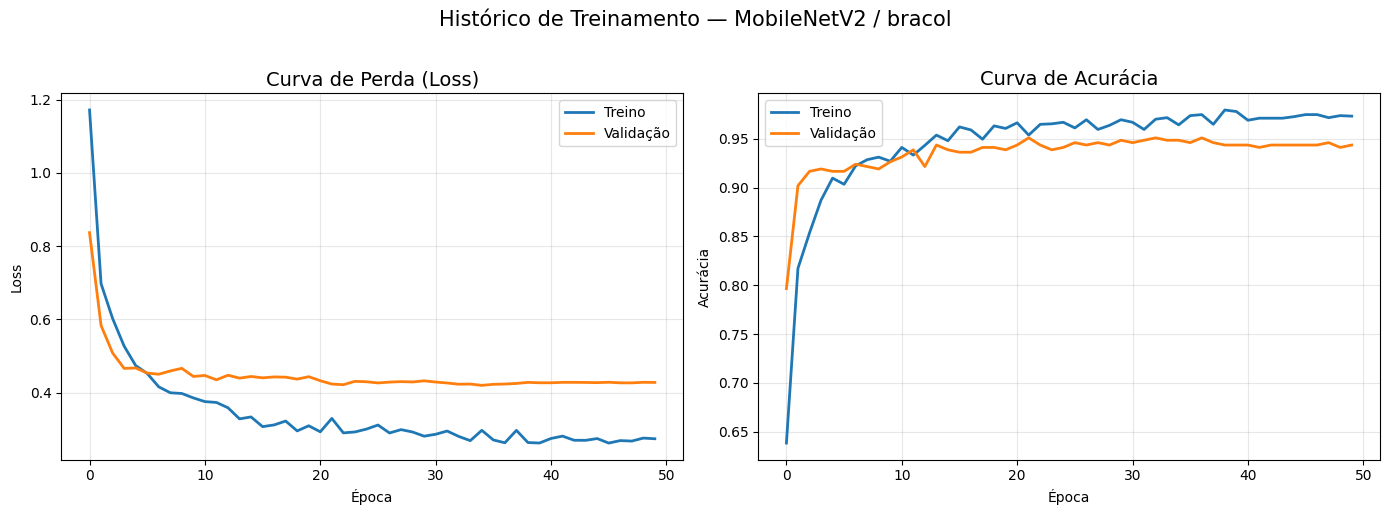

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Loss
axes[0].plot(history.history['loss'], label='Treino', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validação', linewidth=2)
axes[0].set_title('Curva de Perda (Loss)', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva de Acurácia
axes[1].plot(history.history['accuracy'], label='Treino', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
axes[1].set_title('Curva de Acurácia', fontsize=14)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Histórico de Treinamento — {BACKBONE_ATIVO} / {DATASET_ATIVO}', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'curvas_aprendizado_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Avaliação Definitiva no Conjunto de Teste

In [11]:
print("Avaliando o modelo final no conjunto de TESTE (dados nunca vistos)...")
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)

print(f"\nAcurácia no Teste: {test_acc:.4f}")
print(f"Perda no Teste: {test_loss:.4f}")

Avaliando o modelo final no conjunto de TESTE (dados nunca vistos)...
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 400ms/step - accuracy: 0.9734 - loss: 0.2940

Acurácia no Teste: 0.9511
Perda no Teste: 0.3981


# Exportador TensorFlow Lite para Flutter

In [12]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

tflite_path = os.path.join(OUTPUT_DIR, f'{NOME_ARQUIVO}.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"Modelo convertido para TFLite com sucesso! Salvo em: {tflite_path}")

Saved artifact at '/tmp/tmpiask0hy4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_imagem')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136599724286976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136598997962416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136598990959216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599005543616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136598997966112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136598990812992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599091248320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599503084128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599005539392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599147003600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13659971089227

# Latência de Inferência (Benchmark Mobile/Offline)

In [13]:
import time
import numpy as np

N_WARMUP = 10   # inferências de aquecimento (descartadas)
N_RUNS   = 100  # inferências medidas

# Pega um batch do test_dataset e extrai uma única imagem para benchmark de 1 imagem por vez
sample_batch = next(iter(test_dataset))[0]          # shape: (batch, 224, 224, 3)
sample_img   = sample_batch[:1]                     # shape: (1, 224, 224, 3)

# Aquecimento (evita penalidade do JIT/XLA na primeira chamada)
for _ in range(N_WARMUP):
    _ = model(sample_img, training=False)

# Medição de latência — imagem única (simula uso mobile)
tempos = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    _ = model(sample_img, training=False)
    tempos.append((time.perf_counter() - t0) * 1000)  # em ms

latencia_media  = np.mean(tempos)
latencia_p95    = np.percentile(tempos, 95)
latencia_std    = np.std(tempos)

print("── Benchmark de Inferência (Keras / CPU+GPU) ──")
print(f"  Latência média  : {latencia_media:.2f} ms")
print(f"  Desvio padrão   : {latencia_std:.2f} ms")
print(f"  Percentil 95    : {latencia_p95:.2f} ms")
print(f"  FPS equivalente : {1000 / latencia_media:.1f} imagens/s")

# ── Latência do modelo TFLite (o que roda no app) ─────────────────────────
tflite_path = os.path.join(OUTPUT_DIR, f'{NOME_ARQUIVO}.tflite')
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

img_tflite = sample_img.numpy().astype(np.float32)

for _ in range(N_WARMUP):
    interpreter.set_tensor(input_details[0]['index'], img_tflite)
    interpreter.invoke()

tempos_tflite = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    interpreter.set_tensor(input_details[0]['index'], img_tflite)
    interpreter.invoke()
    tempos_tflite.append((time.perf_counter() - t0) * 1000)

lat_tflite_media = np.mean(tempos_tflite)
lat_tflite_p95   = np.percentile(tempos_tflite, 95)

print("\n── Benchmark de Inferência (TFLite quantizado) ──")
print(f"  Latência média  : {lat_tflite_media:.2f} ms")
print(f"  Percentil 95    : {lat_tflite_p95:.2f} ms")
print(f"  FPS equivalente : {1000 / lat_tflite_media:.1f} imagens/s")
print(f"\n  Speedup TFLite vs Keras: {latencia_media / lat_tflite_media:.2f}x")

# Tamanho do arquivo TFLite em disco
tflite_size_kb = os.path.getsize(tflite_path) / 1024
print(f"  Tamanho do modelo TFLite: {tflite_size_kb:.1f} KB ({tflite_size_kb/1024:.2f} MB)")

── Benchmark de Inferência (Keras / CPU+GPU) ──
  Latência média  : 128.09 ms
  Desvio padrão   : 5.30 ms
  Percentil 95    : 137.40 ms
  FPS equivalente : 7.8 imagens/s

── Benchmark de Inferência (TFLite quantizado) ──
  Latência média  : 17.00 ms
  Percentil 95    : 17.82 ms
  FPS equivalente : 58.8 imagens/s

  Speedup TFLite vs Keras: 7.54x
  Tamanho do modelo TFLite: 4498.9 KB (4.39 MB)


# Matriz de confusão e Avaliação Detalhada

Coletando rótulos reais do teste...
Gerando predições com o modelo final...
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 236ms/step


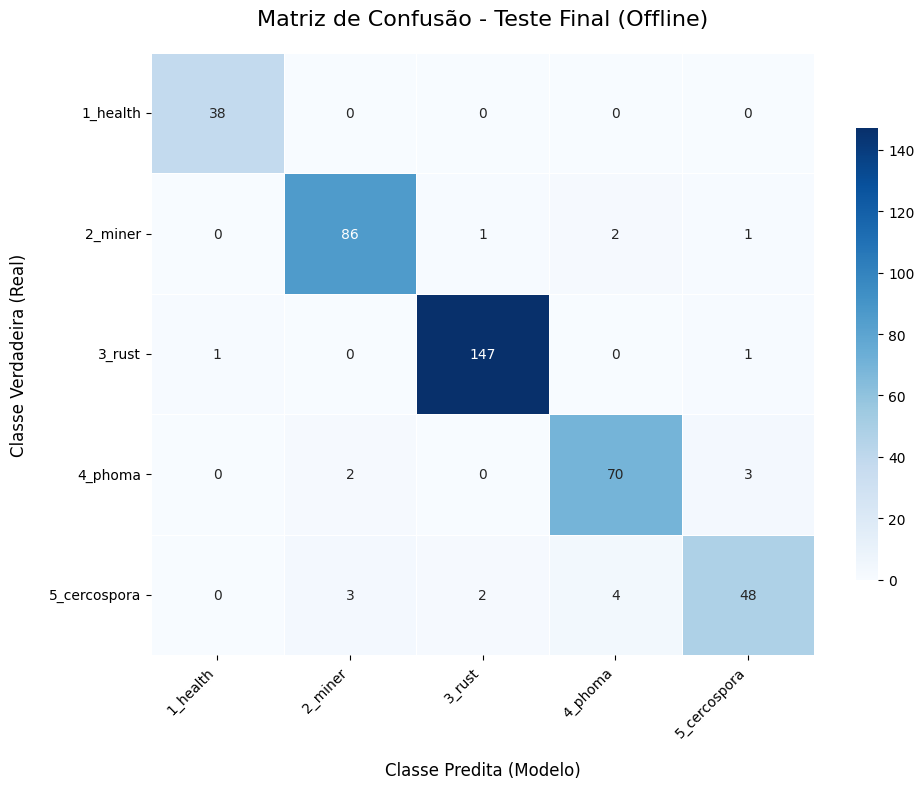


Relatório de Classificação Detalhado (Teste):

              precision    recall  f1-score   support

    1_health       0.97      1.00      0.99        38
     2_miner       0.95      0.96      0.95        90
      3_rust       0.98      0.99      0.98       149
     4_phoma       0.92      0.93      0.93        75
5_cercospora       0.91      0.84      0.87        57

    accuracy                           0.95       409
   macro avg       0.95      0.94      0.94       409
weighted avg       0.95      0.95      0.95       409



In [14]:
# CÉLULA: Matriz de Confusão no Conjunto de Teste
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Coletar os rótulos reais (Ground Truth) do dataset de teste
print("Coletando rótulos reais do teste...")
y_true_test = np.concatenate([y for x, y in test_dataset], axis=0)

# 2. Gerar as predições com o modelo treinado
print("Gerando predições com o modelo final...")
y_pred_probs_test = model.predict(test_dataset)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)

# 3. Calcular a Matriz de Confusão
cm = confusion_matrix(y_true_test, y_pred_test)

# 4. Plotar a Matriz graficamente com Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_geral, yticklabels=class_names_geral,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Matriz de Confusão - Teste Final (Offline)', pad=20, fontsize=16)
plt.ylabel('Classe Verdadeira (Real)', fontsize=12, labelpad=15)
plt.xlabel('Classe Predita (Modelo)', fontsize=12, labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
plt.close()

# 5. Relatório de Classificação (Precision, Recall e F1-Score por classe)
print("\nRelatório de Classificação Detalhado (Teste):\n")
print(classification_report(y_true_test, y_pred_test, target_names=class_names_geral))

# Curvas ROC, Precision-Recall e F1 por Classe


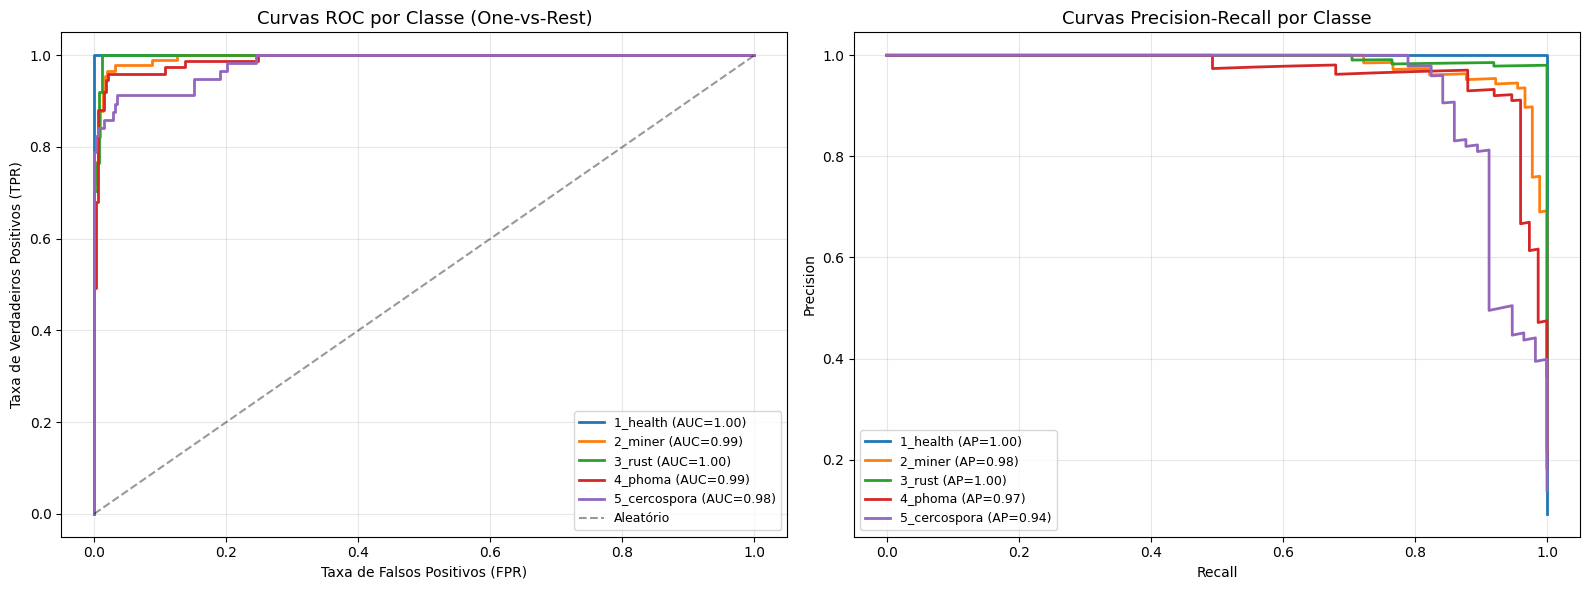

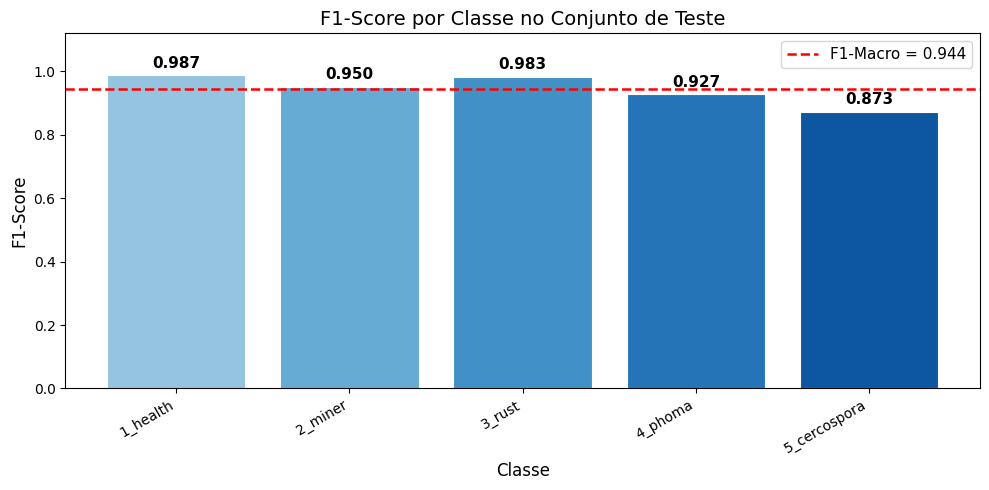

In [15]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, f1_score
from sklearn.preprocessing import label_binarize

n_classes = len(class_names_geral)
# Binariza os rótulos reais para avaliação one-vs-rest
y_true_bin = label_binarize(y_true_test, classes=list(range(n_classes)))

# ── Curvas ROC e Precision-Recall ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, class_name in enumerate(class_names_geral):
    # ROC
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs_test[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC={roc_auc:.2f})')

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs_test[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_pred_probs_test[:, i])
    axes[1].plot(recall, precision, linewidth=2, label=f'{class_name} (AP={ap:.2f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatório')
axes[0].set_title('Curvas ROC por Classe (One-vs-Rest)', fontsize=13)
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Curvas Precision-Recall por Classe', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'curvas_roc_pr_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ── F1-Score por Classe (Gráfico de Barras) ────────────────────────────────
f1_por_classe = f1_score(y_true_test, y_pred_test, average=None)
f1_macro = f1_score(y_true_test, y_pred_test, average='macro')

plt.figure(figsize=(10, 5))
cores = plt.cm.Blues(np.linspace(0.4, 0.85, n_classes))
bars = plt.bar(class_names_geral, f1_por_classe, color=cores, edgecolor='white', linewidth=0.8)
plt.axhline(y=f1_macro, color='red', linestyle='--', linewidth=1.8, label=f'F1-Macro = {f1_macro:.3f}')

for bar, val in zip(bars, f1_por_classe):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('F1-Score por Classe no Conjunto de Teste', fontsize=14)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1.12)
plt.legend(fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'f1_por_classe_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Calibração de Confiança (ECE + Reliability Diagram)

── Calibração de Confiança (Teste) ──
faixa_confianca  confianca_media  acuracia_media  n_amostras
        0.4-0.5         0.497924        0.000000           1
        0.5-0.6         0.550375        0.555556           9
        0.6-0.7         0.656032        1.000000           5
        0.7-0.8         0.755357        0.600000          10
        0.8-0.9         0.869772        0.900000          10
        0.9-1.0         0.991756        0.973262         374
Expected Calibration Error (ECE): 0.0270  (quanto menor, melhor — 0 é calibração perfeita)


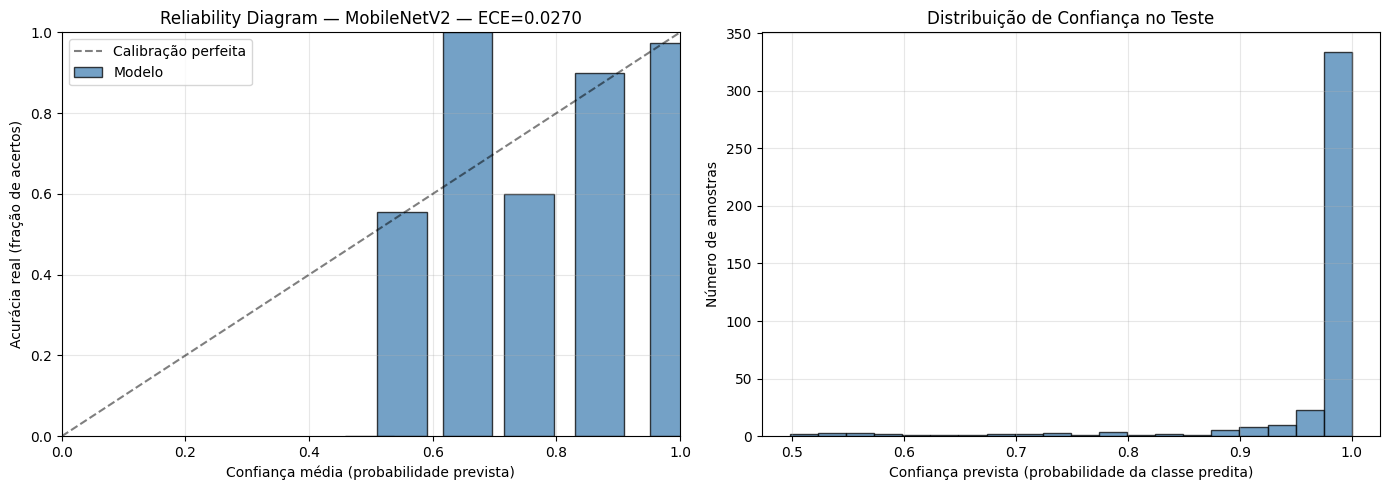

In [16]:
# Mede se a confiança que o modelo reporta (ex.: "Confiança: 100%" na tela do app) reflete
# de fato a probabilidade real de acerto. Um modelo bem calibrado errando ~10% das vezes
# quando diz "90% de confiança" tem um reliability diagram colado na diagonal; se a barra
# fica sistematicamente ABAIXO da diagonal, o modelo é overconfident — problema comum em
# redes profundas modernas (Guo et al., 2017, "On Calibration of Modern Neural Networks").
def calcular_calibracao(y_true, y_pred, y_pred_probs, n_bins=10):
    confidences = y_pred_probs[np.arange(len(y_pred)), y_pred]
    corretos = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.clip(np.digitize(confidences, bin_edges[1:-1]), 0, n_bins - 1)

    registros = []
    ece = 0.0
    n_total = len(confidences)
    for b in range(n_bins):
        mask = bin_ids == b
        n_bin = int(mask.sum())
        if n_bin == 0:
            continue
        conf_media = float(confidences[mask].mean())
        acc_media = float(corretos[mask].mean())
        peso = n_bin / n_total
        ece += peso * abs(acc_media - conf_media)
        registros.append({
            'faixa_confianca': f'{bin_edges[b]:.1f}-{bin_edges[b + 1]:.1f}',
            'confianca_media': conf_media,
            'acuracia_media':  acc_media,
            'n_amostras':      n_bin,
        })

    return pd.DataFrame(registros), ece


df_calibracao, ece_valor = calcular_calibracao(y_true_test, y_pred_test, y_pred_probs_test)
print("── Calibração de Confiança (Teste) ──")
print(df_calibracao.to_string(index=False))
print(f"Expected Calibration Error (ECE): {ece_valor:.4f}  (quanto menor, melhor — 0 é calibração perfeita)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reliability Diagram
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibração perfeita')
axes[0].bar(df_calibracao['confianca_media'], df_calibracao['acuracia_media'],
            width=0.08, alpha=0.75, edgecolor='black', color='steelblue', label='Modelo')
axes[0].set_xlabel('Confiança média (probabilidade prevista)')
axes[0].set_ylabel('Acurácia real (fração de acertos)')
axes[0].set_title(f'Reliability Diagram — {BACKBONE_ATIVO} — ECE={ece_valor:.4f}', fontsize=12)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma de confiança
confidences_all = y_pred_probs_test[np.arange(len(y_pred_test)), y_pred_test]
axes[1].hist(confidences_all, bins=20, color='steelblue', edgecolor='black', alpha=0.75)
axes[1].set_xlabel('Confiança prevista (probabilidade da classe predita)')
axes[1].set_ylabel('Número de amostras')
axes[1].set_title('Distribuição de Confiança no Teste', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'calibracao_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Correção da Calibração — Temperature Scaling

Ajustando temperatura no conjunto de validação...
Temperatura ajustada: T = 1.5518
── Calibração APÓS Temperature Scaling (Teste) ──
faixa_confianca  confianca_media  acuracia_media  n_amostras
        0.4-0.5         0.468016        0.600000           5
        0.5-0.6         0.544233        0.555556           9
        0.6-0.7         0.651858        0.714286          14
        0.7-0.8         0.779274        0.846154          13
        0.8-0.9         0.855767        0.944444          36
        0.9-1.0         0.982144        0.981928         332
ECE antes: 0.0270  |  ECE depois: 0.0141


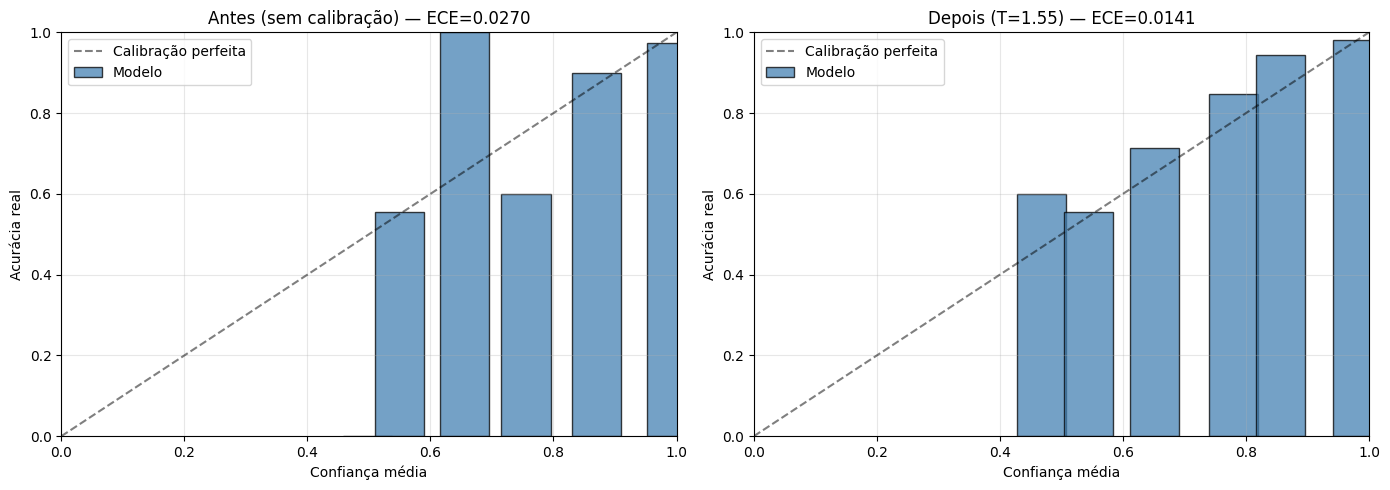

A partir daqui, y_pred_probs_calibrado contém as probabilidades corrigidas -- use-as (em vez de y_pred_probs_test) na interface do app para exibir uma confiança que reflete melhor a taxa de acerto real do modelo.


In [17]:
# Temperature Scaling (Guo et al., 2017) -- a célula anterior mostrou como o modelo está
# calibrado. Esta célula CORRIGE o vício de confiança sem mudar nenhuma predição (o argmax
# é o mesmo) -- só reescala os LOGITS (pré-softmax) por um único escalar T, ajustado no
# conjunto de VALIDAÇÃO (nunca no teste, para não vazar informação), minimizando a
# log-verossimilhança negativa (NLL). Como a camada final do Keras já aplica softmax
# internamente ('predicao_final', activation='softmax'), os logits não estão expostos
# diretamente -- são recuperados aplicando manualmente o kernel/bias dessa última camada
# Dense sobre a saída da penúltima camada (mesmo truque usado em qualquer arquitetura de
# saída, independente do número de blocos densos escolhido pelo Optuna).
from scipy.optimize import minimize_scalar

def obter_logits(modelo, dataset):
    extrator_features = tf.keras.Model(modelo.input, modelo.layers[-2].output)
    W, b = modelo.layers[-1].get_weights()
    logits_partes = []
    for batch_x, _ in dataset:
        feats = extrator_features(batch_x, training=False).numpy()
        logits_partes.append(feats @ W + b)
    return np.concatenate(logits_partes, axis=0)


def calcular_nll(logits, labels, T):
    logits_T = logits / T
    logits_T = logits_T - logits_T.max(axis=1, keepdims=True)
    exp = np.exp(logits_T)
    probs = exp / exp.sum(axis=1, keepdims=True)
    probs_true = probs[np.arange(len(labels)), labels]
    return -np.mean(np.log(np.clip(probs_true, 1e-12, 1.0)))


print("Ajustando temperatura no conjunto de validação...")
logits_val = obter_logits(model, val_dataset)
y_true_val = np.concatenate([y for x, y in val_dataset], axis=0)

resultado_temp = minimize_scalar(
    lambda T: calcular_nll(logits_val, y_true_val, T),
    bounds=(0.05, 10.0), method='bounded'
)
T = resultado_temp.x
print(f"Temperatura ajustada: T = {T:.4f}")

# Aplica a temperatura aos logits do TESTE (nunca vistos durante o ajuste de T)
logits_test = obter_logits(model, test_dataset)
logits_test_cal = logits_test / T
exp_cal = np.exp(logits_test_cal - logits_test_cal.max(axis=1, keepdims=True))
y_pred_probs_calibrado = exp_cal / exp_cal.sum(axis=1, keepdims=True)

df_calibracao_pos, ece_pos = calcular_calibracao(y_true_test, y_pred_test, y_pred_probs_calibrado)
print("── Calibração APÓS Temperature Scaling (Teste) ──")
print(df_calibracao_pos.to_string(index=False))
print(f"ECE antes: {ece_valor:.4f}  |  ECE depois: {ece_pos:.4f}")

# ── Comparação visual: antes x depois ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_plot, ece_plot, titulo in [
    (axes[0], df_calibracao, ece_valor, 'Antes (sem calibração)'),
    (axes[1], df_calibracao_pos, ece_pos, f'Depois (T={T:.2f})'),
]:
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibração perfeita')
    ax.bar(df_plot['confianca_media'], df_plot['acuracia_media'],
           width=0.08, alpha=0.75, edgecolor='black', color='steelblue', label='Modelo')
    ax.set_xlabel('Confiança média')
    ax.set_ylabel('Acurácia real')
    ax.set_title(f'{titulo} — ECE={ece_plot:.4f}', fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'calibracao_temperature_scaling_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("A partir daqui, y_pred_probs_calibrado contém as probabilidades corrigidas -- use-as "
      "(em vez de y_pred_probs_test) na interface do app para exibir uma confiança que reflete "
      "melhor a taxa de acerto real do modelo.")

# Limiar de Abstenção Baseado em Confiança (Predição Seletiva)

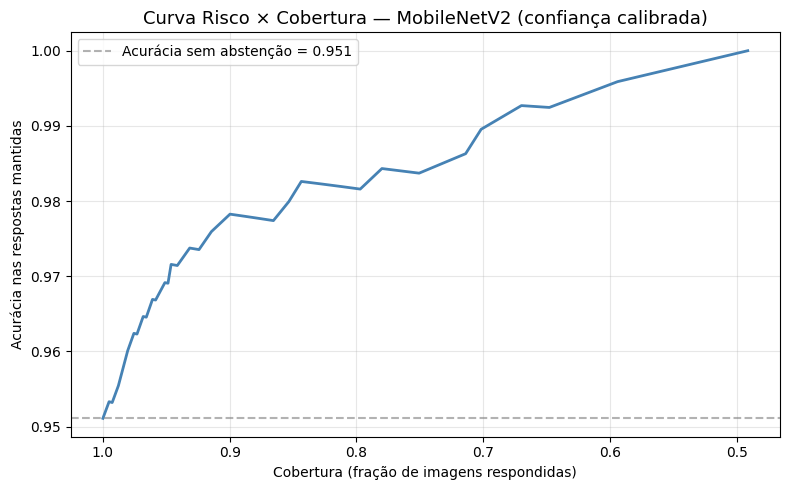

── Predição Seletiva — Cobertura × Acurácia por limiar de confiança ──
 limiar  cobertura (%)  acurácia nas mantidas  n_abstidas  erros_evitados  erros_que_ainda_passam
   0.50           98.8                 0.9554           5               2                      18
   0.60           96.6                 0.9646          14               6                      14
   0.70           93.2                 0.9738          28              10                      10
   0.80           90.0                 0.9783          41              12                       8
   0.90           81.2                 0.9819          77              14                       6
   0.95           70.2                 0.9895         122              17                       3
   0.99           49.1                 1.0000         208              20                       0
Resultados salvos em: outputs/MobileNetV2_bracol/abstencao_MobileNetV2_bracol.csv
Escolha o limiar considerando o trade-off do seu caso de uso: l

In [18]:
# A calibração mostrou o quanto o modelo é overconfident. Uma forma prática de lidar com
# isso no app é a PREDIÇÃO SELETIVA: em vez de sempre mostrar um diagnóstico, o app pode
# "abster-se" (pedir outra foto, ou avisar o produtor que o resultado é incerto) quando a
# confiança CALIBRADA (y_pred_probs_calibrado, da célula de Temperature Scaling) fica abaixo
# de um limiar.
confidences_cal = y_pred_probs_calibrado[np.arange(len(y_pred_test)), y_pred_test]
corretos_bin = (y_pred_test == y_true_test)

# ── Curva Risco × Cobertura (Risk-Coverage) ─────────────────────────
# Cobertura = fração de amostras que o modelo aceitaria responder (confiança >= limiar).
# Acurácia nas mantidas = qualidade das respostas que o modelo de fato daria.
limiares_curva = np.arange(0.0, 1.001, 0.01)
coberturas, acuracias_mantidas = [], []
for t in limiares_curva:
    mask = confidences_cal >= t
    coberturas.append(mask.mean())
    acuracias_mantidas.append(corretos_bin[mask].mean() if mask.sum() > 0 else np.nan)

plt.figure(figsize=(8, 5))
plt.plot(coberturas, acuracias_mantidas, linewidth=2, color='steelblue')
plt.axhline(y=corretos_bin.mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'Acurácia sem abstenção = {corretos_bin.mean():.3f}')
plt.xlabel('Cobertura (fração de imagens respondidas)')
plt.ylabel('Acurácia nas respostas mantidas')
plt.title(f'Curva Risco × Cobertura — {BACKBONE_ATIVO} (confiança calibrada)', fontsize=13)
plt.gca().invert_xaxis()  # cobertura decrescente da esquerda pra direita = limiar crescente
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'risco_cobertura_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ── Tabela para limiares candidatos ────────────────────────────
LIMIARES_CANDIDATOS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
registros_abstencao = []
for t in LIMIARES_CANDIDATOS:
    mask = confidences_cal >= t
    n_mantidas = int(mask.sum())
    n_abstidas = int(len(mask) - n_mantidas)
    acc_mantidas = float(corretos_bin[mask].mean()) if n_mantidas > 0 else None
    erros_evitados = int(((~mask) & (~corretos_bin)).sum())   # erros que ficam de fora (abstidos)
    erros_que_passam = int((mask & (~corretos_bin)).sum())     # erros que o app mostraria mesmo assim
    registros_abstencao.append({
        'limiar':                  t,
        'cobertura (%)':           round(100 * n_mantidas / len(mask), 1),
        'acurácia nas mantidas':   round(acc_mantidas, 4) if acc_mantidas is not None else None,
        'n_abstidas':              n_abstidas,
        'erros_evitados':          erros_evitados,
        'erros_que_ainda_passam':  erros_que_passam,
    })

df_abstencao = pd.DataFrame(registros_abstencao)
print("── Predição Seletiva — Cobertura × Acurácia por limiar de confiança ──")
print(df_abstencao.to_string(index=False))

abstencao_path = os.path.join(OUTPUT_DIR, f'abstencao_{NOME_ARQUIVO}.csv')
df_abstencao.to_csv(abstencao_path, index=False)
print(f"Resultados salvos em: {abstencao_path}")
print("Escolha o limiar considerando o trade-off do seu caso de uso: limiares mais altos "
      "abstêm mais (o produtor precisa tirar outra foto com mais frequência), mas evitam "
      "mais diagnósticos errados mostrados com falsa confiança.")

# Estrutura Base para o Grad-CAM

In [19]:
# CÉLULA 10: Inteligência Artificial Explicável (Grad-CAM)
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, pred_index=None):
    # 1. Encontrar o índice exato onde o backbone está inserido no modelo
    #    O backbone sempre recebe o nome fixo "base_model" em create_model()
    base_model_idx = model.layers.index(model.get_layer("base_model"))

    # 2. Executar as camadas iniciais (o pré-processamento) manualmente
    x = img_array
    for layer in model.layers[:base_model_idx]:
        # Ignoramos a InputLayer, pois ela é apenas um "placeholder"
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue
        x = layer(x)

    # 3. Resgatar o extrator de características (backbone)
    base_model = model.layers[base_model_idx]

    # 4. Abrir a gravação de gradientes do TensorFlow
    with tf.GradientTape() as tape:
        # Passamos a imagem pré-processada pelo modelo base
        # Como usamos include_top=False, a saída JÁ É o mapa de características convolucional final!
        feature_maps = base_model(x, training=False)

        # Dizer expressamente ao TensorFlow para monitorar essa variável
        tape.watch(feature_maps)

        # Continuar passando a imagem pelas camadas restantes (Pooling, Denses, Dropout)
        out = feature_maps
        for layer in model.layers[base_model_idx + 1:]:
            out = layer(out, training=False)

        preds = out

        # Isolar a predição da classe de interesse
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 5. Calcular os gradientes da classe predita em relação aos mapas de características
    grads = tape.gradient(class_channel, feature_maps)

    # 6. Agrupar os gradientes (Tirando a média espacial - Global Average Pooling dos gradientes)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Multiplicar cada canal de característica pelo seu "peso" de importância (o gradiente)
    feature_maps = feature_maps[0]
    heatmap = feature_maps @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 8. Aplicar ReLU (remover valores negativos) e normalizar a imagem do calor entre 0 e 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.5):
    # Carregar imagem original
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Redimensionar o heatmap para o tamanho da imagem
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Converter o heatmap para cores (padrão Jet)
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Sobrepor as imagens
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
    superimposed_img = jet_heatmap * alpha + (img.astype("float32") / 255)
    superimposed_img = np.clip(superimposed_img, 0, 1)

    # Visualizar
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Imagem Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM (Justificativa Visual)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    plt.close()

[1_health] Acertos: 38 | Erros: 0


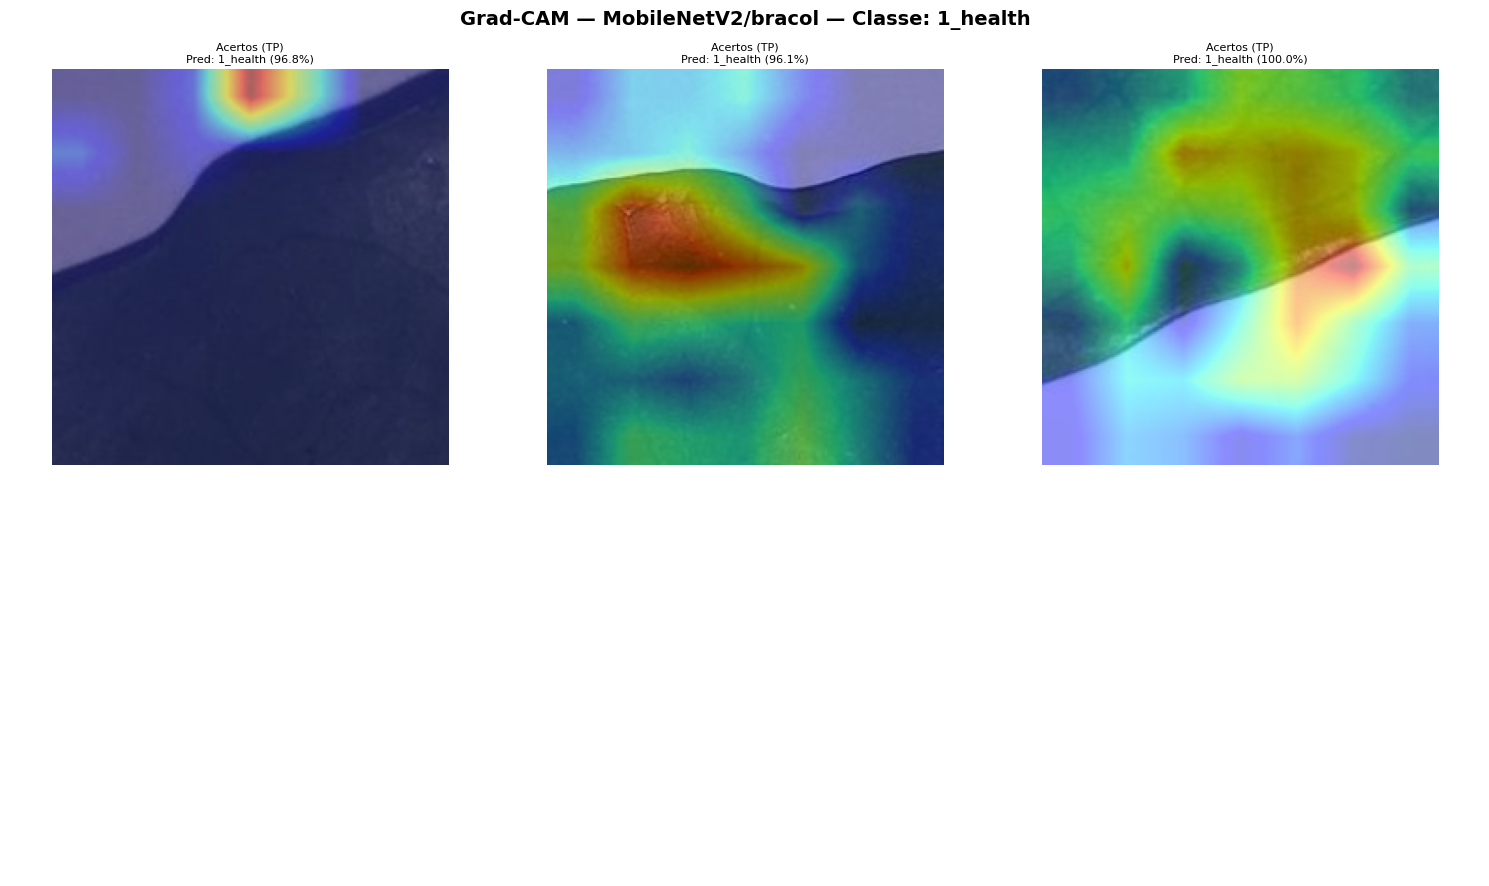

[2_miner] Acertos: 86 | Erros: 4


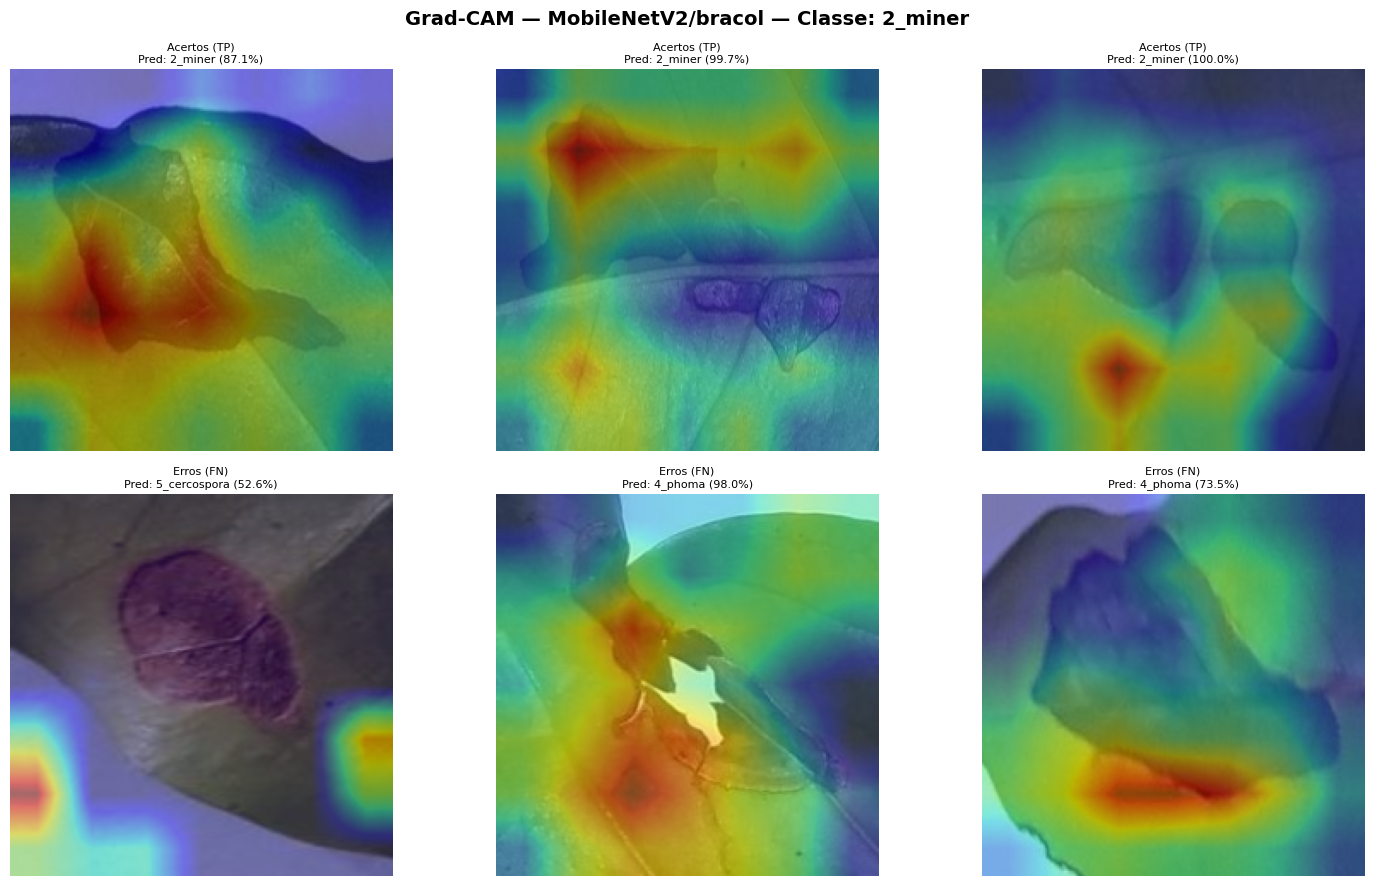

[3_rust] Acertos: 147 | Erros: 2


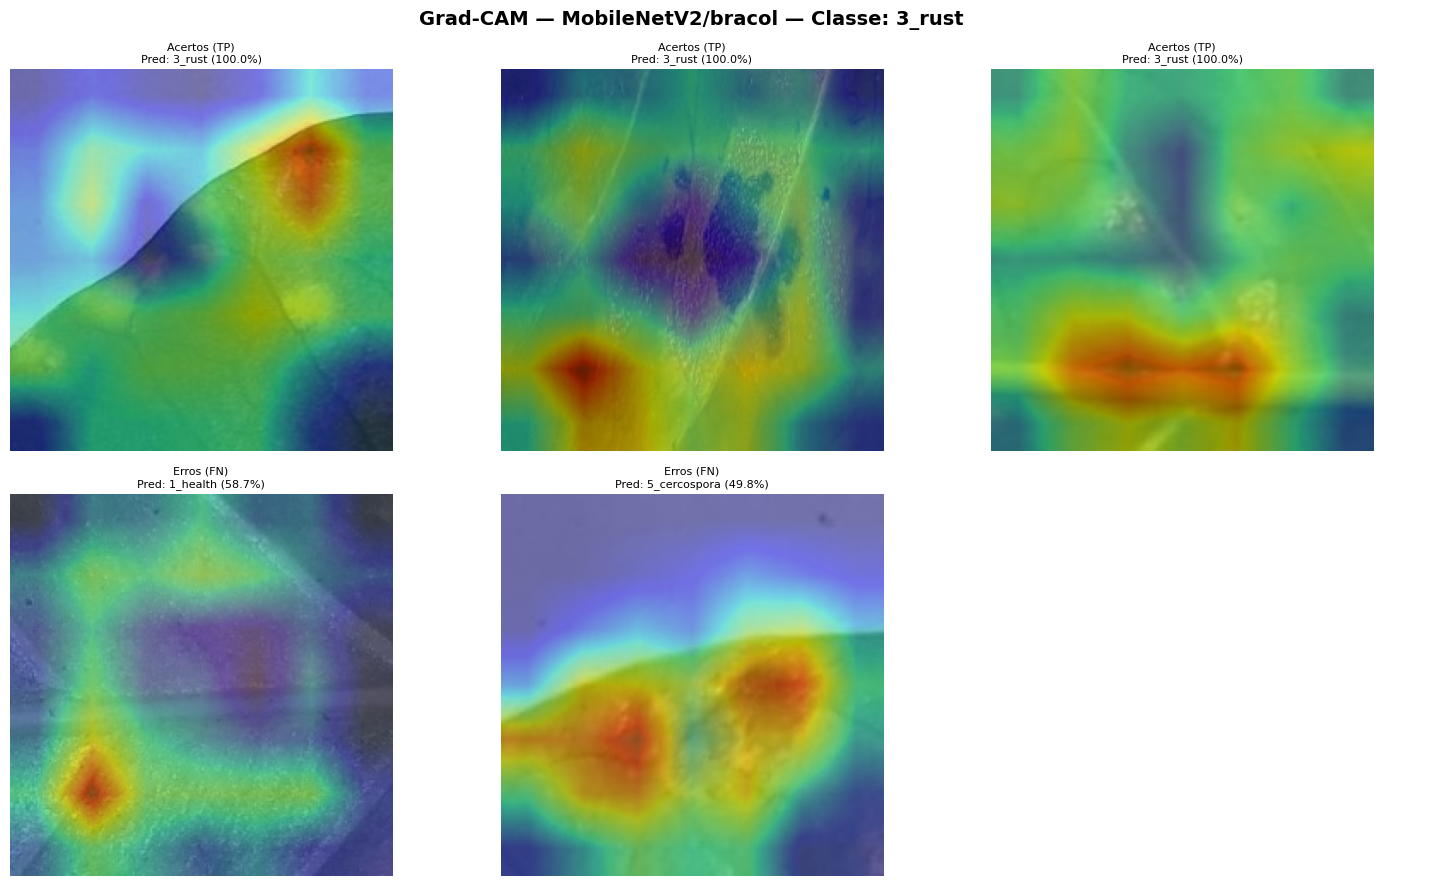

[4_phoma] Acertos: 70 | Erros: 5


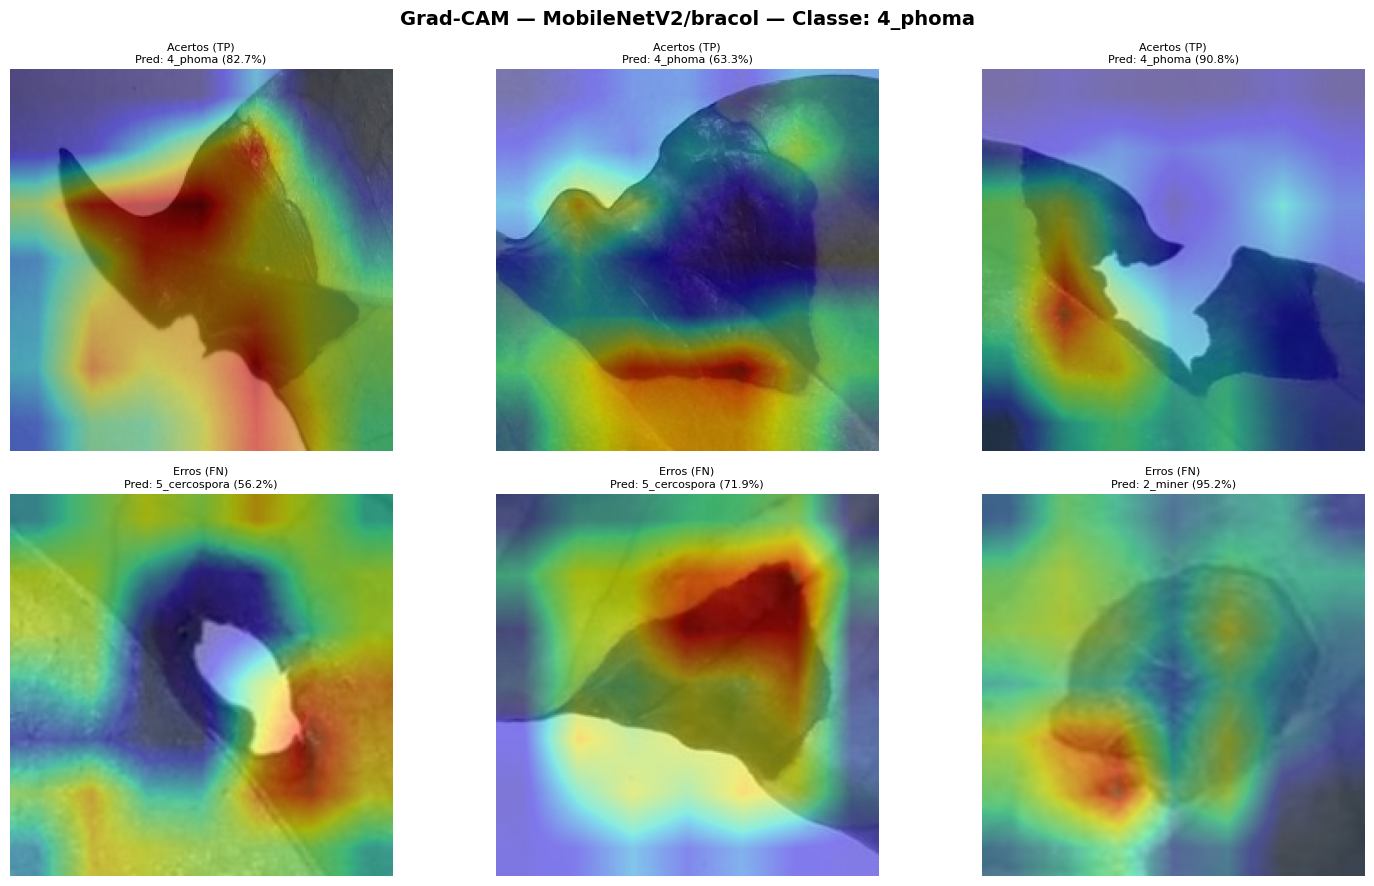

[5_cercospora] Acertos: 48 | Erros: 9


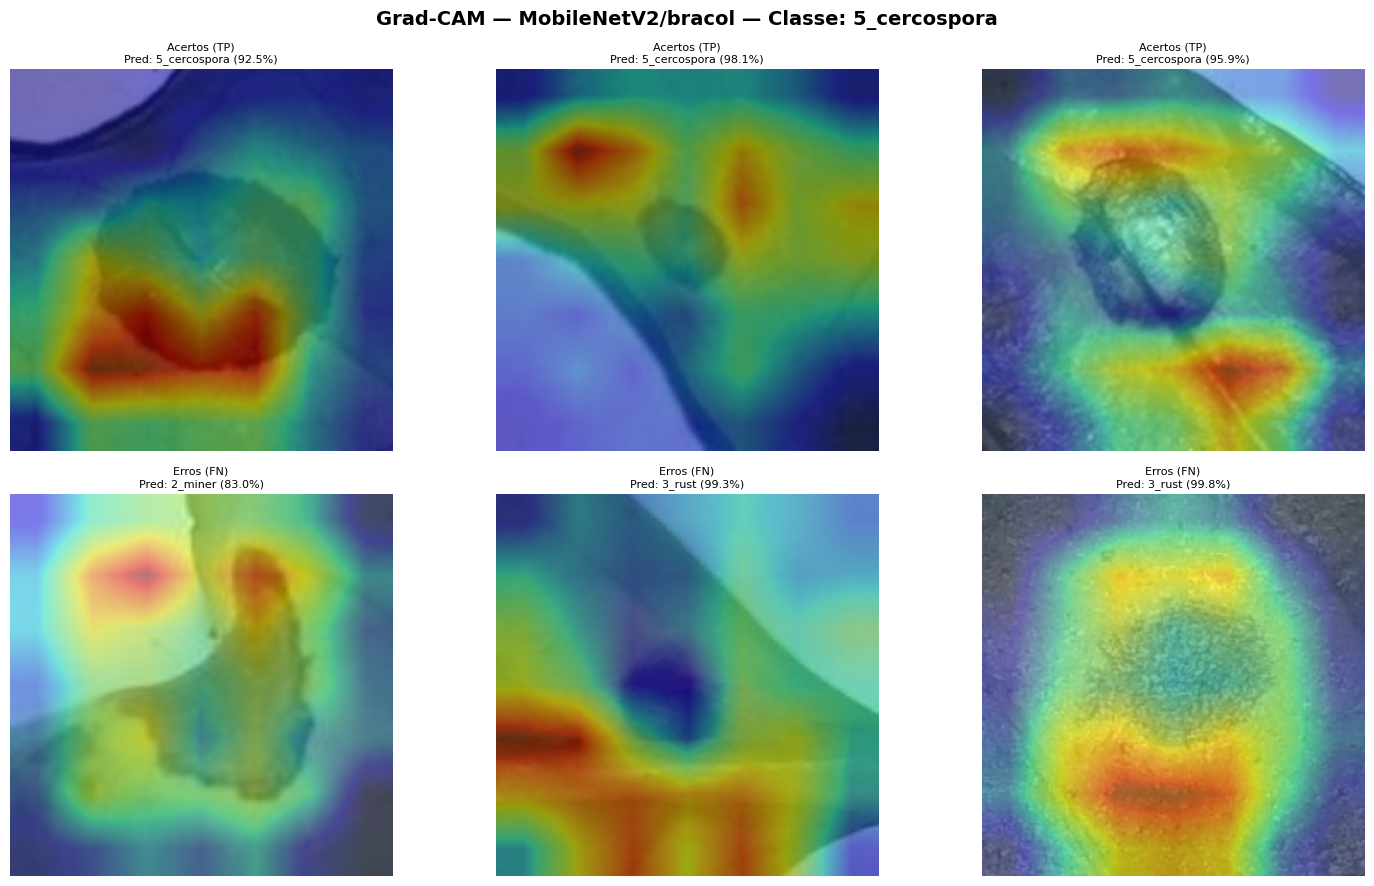

In [20]:
import cv2
import pathlib

N_POR_CLASSE = 3  # imagens exibidas por categoria (acertos e erros)

IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def carregar_imagem(caminho, target_size=(224, 224)):
    """Carrega imagem do disco → (img_rgb uint8, img_array float32 com batch dim)."""
    img = cv2.imread(str(caminho))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, target_size)
    img_array = np.expand_dims(img_rgb.astype(np.float32), axis=0)
    return img_rgb, img_array

def gerar_overlay_gradcam(img_rgb, heatmap, alpha=0.45):
    """Sobrepõe o heatmap Grad-CAM sobre a imagem original."""
    hm = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    hm_uint8 = np.uint8(255 * hm)
    jet_colors = plt.colormaps.get_cmap("jet")(np.arange(256))[:, :3]
    overlay = jet_colors[hm_uint8] * alpha + img_rgb.astype(np.float32) / 255 * (1 - alpha)
    return np.clip(overlay, 0, 1)

# ── Mapeamento: arquivo → predição (mesma ordem do test_dataset shuffle=False) ──
all_test_info = []
for class_idx, class_name in enumerate(class_names_geral):
    class_dir = pathlib.Path(test_dir) / class_name
    img_files = sorted([p for p in class_dir.iterdir() if p.suffix.lower() in IMG_EXTENSIONS])
    for img_path in img_files:
        all_test_info.append({'path': str(img_path), 'true_label': class_idx})

for i, info in enumerate(all_test_info):
    info['pred_label']  = int(y_pred_test[i])
    info['confidence']  = float(y_pred_probs_test[i, int(y_pred_test[i])])

# ── Grad-CAM em lote: acertos (TP) e erros (FN) por classe ─────────────────
for class_idx, class_name in enumerate(class_names_geral):
    acertos = [d for d in all_test_info if d['true_label'] == class_idx and d['pred_label'] == class_idx]
    erros   = [d for d in all_test_info if d['true_label'] == class_idx and d['pred_label'] != class_idx]

    samples_ok  = acertos[:N_POR_CLASSE]
    samples_err = erros[:N_POR_CLASSE]
    print(f"[{class_name}] Acertos: {len(acertos)} | Erros: {len(erros)}")

    fig, axes = plt.subplots(2, N_POR_CLASSE, figsize=(5 * N_POR_CLASSE, 9))
    fig.suptitle(f'Grad-CAM — {BACKBONE_ATIVO}/{DATASET_ATIVO} — Classe: {class_name}', fontsize=14, fontweight='bold')

    for row, (rotulo, samples) in enumerate([('Acertos (TP)', samples_ok), ('Erros (FN)', samples_err)]):
        for col in range(N_POR_CLASSE):
            ax = axes[row, col]
            if col < len(samples):
                d = samples[col]
                img_rgb, img_array = carregar_imagem(d['path'])
                heatmap = make_gradcam_heatmap(img_array, model)
                overlay = gerar_overlay_gradcam(img_rgb, heatmap)
                ax.imshow(overlay)
                pred_name = class_names_geral[d['pred_label']]
                ax.set_title(f"{rotulo}\nPred: {pred_name} ({d['confidence']*100:.1f}%)", fontsize=8)
            else:
                ax.set_facecolor('#eeeeee')
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'gradcam_{NOME_ARQUIVO}_{class_name}.png'), dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()

# Avaliação Quantitativa do Grad-CAM (Insertion/Deletion AUC)

In [21]:
import pandas as pd

# Referência: Petsiuk, Das & Saenko (2018) — RISE: Randomized Input Sampling for
# Explanation of Black-box Models. Insertion/Deletion AUC mede objetivamente se o
# heatmap do Grad-CAM aponta para as regiões que o modelo REALMENTE usa na decisão,
# complementando a inspeção visual (que é subjetiva).
N_FIDELIDADE_POR_CLASSE = 3   # mesmas amostras usadas no Grad-CAM em lote
BLUR_KSIZE = 31                # kernel do borrão usado como "imagem base" de baixa informação

# np.trapezoid substitui np.trapz (deprecado a partir do NumPy 2.0)
_trapz = getattr(np, 'trapezoid', np.trapz)

def curva_insercao_delecao(model, img_rgb, heatmap, class_idx, modo, blur_ksize=BLUR_KSIZE):
    """
    Revela ('insertion') ou apaga ('deletion') progressivamente os blocos da imagem,
    ordenados pela importância do Grad-CAM (do mais para o menos importante), e mede
    como a probabilidade da classe predita reage a cada passo.

    Insertion: parte de uma imagem borrada (pouca informação) e revela as regiões mais
    importantes primeiro — se o Grad-CAM for fiel, a confiança deve SUBIR rápido
    (AUC alta é melhor).
    Deletion: parte da imagem original e apaga as regiões mais importantes primeiro —
    se o Grad-CAM for fiel, a confiança deve CAIR rápido (AUC baixa é melhor).

    Retorna (fracoes_reveladas, probabilidades, AUC).
    """
    H, W = img_rgb.shape[:2]
    hh, hw = heatmap.shape
    ordem = np.argsort(heatmap.flatten())[::-1]  # células do heatmap, mais importante primeiro
    bh, bw = H // hh, W // hw                     # tamanho de cada bloco em pixels

    blur = cv2.GaussianBlur(img_rgb, (blur_ksize, blur_ksize), 0)
    base  = blur if modo == 'insertion' else img_rgb
    fonte = img_rgb if modo == 'insertion' else blur

    frames = [base.astype(np.float32).copy()]
    atual = base.astype(np.float32).copy()
    for idx in ordem:
        r, c = divmod(int(idx), hw)
        y0, y1 = r * bh, min((r + 1) * bh, H)
        x0, x1 = c * bw, min((c + 1) * bw, W)
        atual = atual.copy()
        atual[y0:y1, x0:x1] = fonte[y0:y1, x0:x1]
        frames.append(atual)

    batch = np.stack(frames, axis=0)
    probs = model.predict(batch, verbose=0)[:, class_idx]
    fracoes = np.linspace(0, 1, len(probs))
    auc_val = float(_trapz(probs, fracoes))
    return fracoes, probs, auc_val


print("Avaliando fidelidade do Grad-CAM via Insertion/Deletion AUC (pode demorar alguns minutos)...")
registros_fidelidade = []
for class_idx, class_name in enumerate(class_names_geral):
    acertos = [d for d in all_test_info if d['true_label'] == class_idx and d['pred_label'] == class_idx]
    for d in acertos[:N_FIDELIDADE_POR_CLASSE]:
        img_rgb, img_array = carregar_imagem(d['path'])
        heatmap = make_gradcam_heatmap(img_array, model, pred_index=d['pred_label'])

        _, _, auc_ins = curva_insercao_delecao(model, img_rgb, heatmap, d['pred_label'], modo='insertion')
        _, _, auc_del = curva_insercao_delecao(model, img_rgb, heatmap, d['pred_label'], modo='deletion')

        registros_fidelidade.append({
            'classe':           class_name,
            'arquivo':          pathlib.Path(d['path']).name,
            'insertion_auc':    auc_ins,
            'deletion_auc':     auc_del,
            'score_fidelidade': auc_ins - auc_del,   # quanto maior, mais fiel o Grad-CAM
        })

df_fidelidade = pd.DataFrame(registros_fidelidade)
print("\n── Fidelidade do Grad-CAM por amostra ──")
print(df_fidelidade.to_string(index=False))

resumo_fidelidade = df_fidelidade.groupby('classe')[['insertion_auc', 'deletion_auc', 'score_fidelidade']].mean()
print("\n── Fidelidade média por classe ──")
print(resumo_fidelidade.to_string())

print(f"\n── Fidelidade média geral ({len(df_fidelidade)} amostras) ──")
print(f"  Insertion AUC  : {df_fidelidade['insertion_auc'].mean():.4f} (quanto maior, melhor)")
print(f"  Deletion AUC   : {df_fidelidade['deletion_auc'].mean():.4f} (quanto menor, melhor)")
print(f"  Score (Ins-Del): {df_fidelidade['score_fidelidade'].mean():.4f}")

fidelidade_path = os.path.join(OUTPUT_DIR, f'gradcam_fidelidade_{NOME_ARQUIVO}.csv')
df_fidelidade.to_csv(fidelidade_path, index=False)
print(f"\nResultados salvos em: {fidelidade_path}")

Avaliando fidelidade do Grad-CAM via Insertion/Deletion AUC (pode demorar alguns minutos)...

── Fidelidade do Grad-CAM por amostra ──
      classe                      arquivo  insertion_auc  deletion_auc  score_fidelidade
    1_health 1048_0483_0177_0212_0190.jpg       0.750762      0.790241         -0.039479
    1_health  104_0831_0211_0238_0213.jpg       0.876897      0.875130          0.001766
    1_health  106_1336_0620_0188_0195.jpg       0.727253      0.624428          0.102826
     2_miner 1010_1143_0158_0323_0245.jpg       0.324404      0.087904          0.236500
     2_miner 1019_0595_0362_0409_0255.jpg       0.383668      0.587791         -0.204123
     2_miner 1029_1340_0452_0262_0207.jpg       0.554507      0.587053         -0.032546
      3_rust  101_0359_0208_0244_0240.jpg       0.950758      0.664869          0.285889
      3_rust 1034_0825_0562_0401_0231.jpg       0.999953      0.996944          0.003009
      3_rust 1036_1348_0376_0184_0194.jpg       0.998342      0.

# XAI — LIME (Explicabilidade por Superpixels)


Gerando explicações LIME por classe (pode demorar alguns minutos)...


  0%|          | 0/1000 [00:00<?, ?it/s]

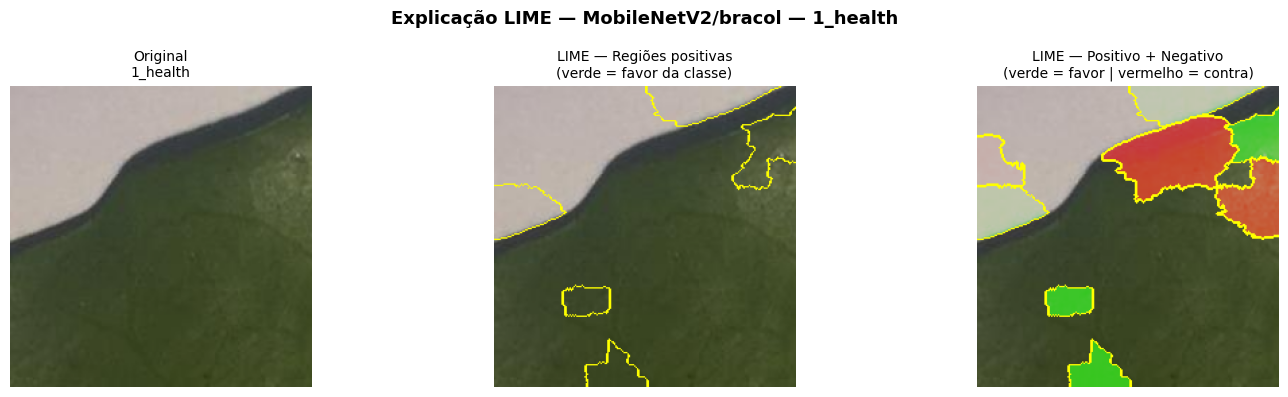

  [1_health] OK


  0%|          | 0/1000 [00:00<?, ?it/s]

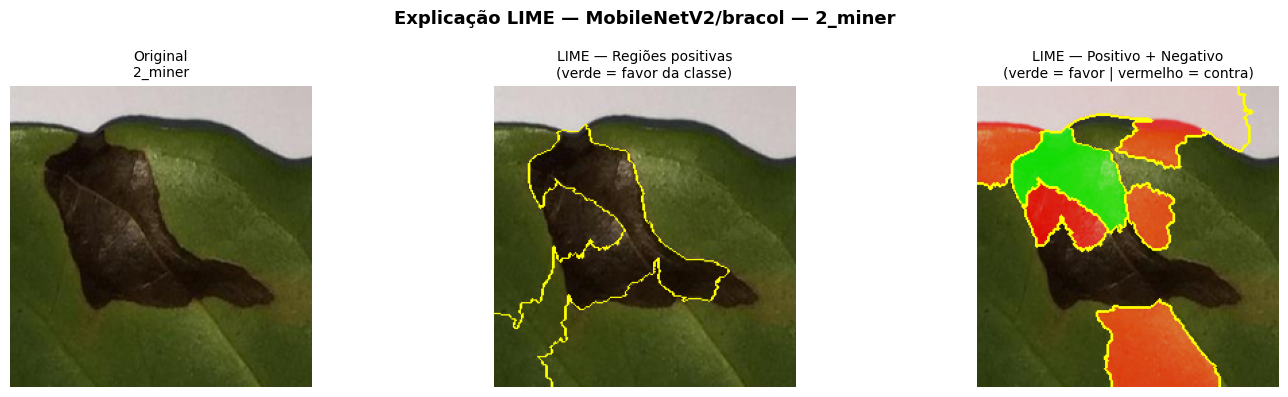

  [2_miner] OK


  0%|          | 0/1000 [00:00<?, ?it/s]

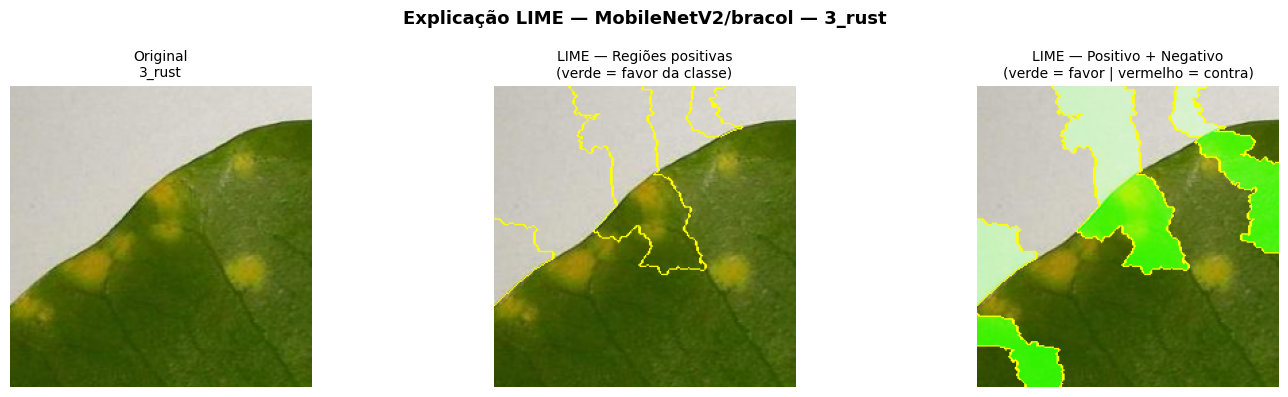

  [3_rust] OK


  0%|          | 0/1000 [00:00<?, ?it/s]

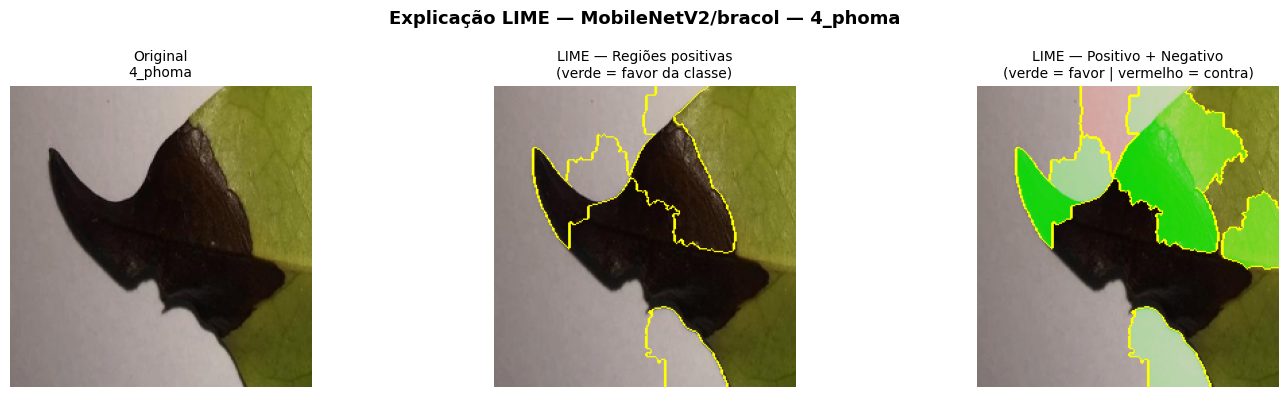

  [4_phoma] OK


  0%|          | 0/1000 [00:00<?, ?it/s]

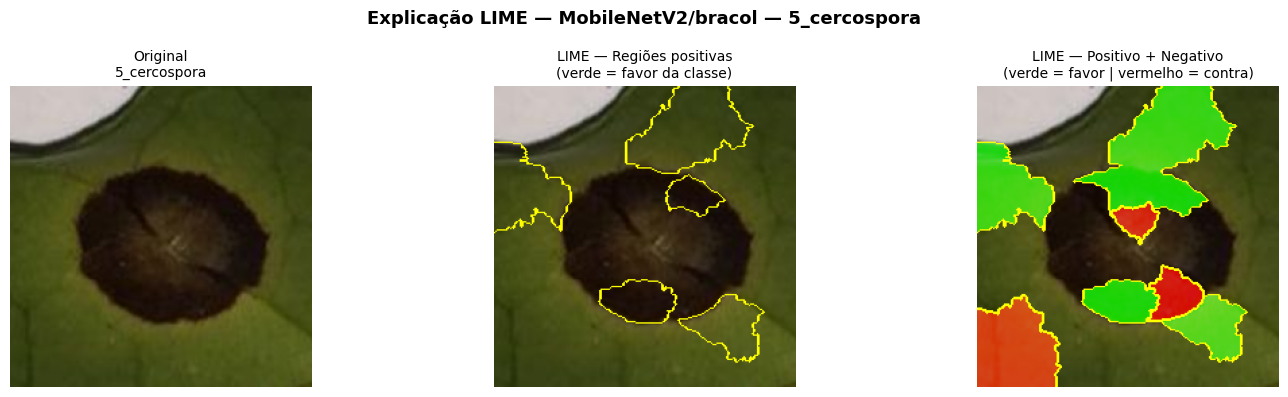

  [5_cercospora] OK


In [22]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def predict_fn_lime(images):
    """
    Wrapper de predição para o LIME.
    O LIME passa imagens no mesmo formato da entrada (uint8, 0-255).
    O modelo aplica preprocess_input internamente, então basta converter para float32.
    """
    return model.predict(images.astype(np.float32), verbose=0)

explainer_lime = lime_image.LimeImageExplainer(random_state=SEED)
N_LIME_SAMPLES = 1000  # perturbações por explicação (mais = mais preciso, mais lento)

print("Gerando explicações LIME por classe (pode demorar alguns minutos)...")
for class_idx, class_name in enumerate(class_names_geral):
    acertos = [d for d in all_test_info if d['true_label'] == class_idx and d['pred_label'] == class_idx]
    if not acertos:
        print(f"  [{class_name}] Sem acertos — pulando.")
        continue

    img_rgb, _ = carregar_imagem(acertos[0]['path'])

    explanation = explainer_lime.explain_instance(
        img_rgb,
        predict_fn_lime,
        top_labels=1,
        hide_color=0,
        num_samples=N_LIME_SAMPLES,
        random_seed=SEED,
    )

    # Regiões que contribuem positivamente para a classe predita
    temp_pos, mask_pos = explanation.get_image_and_mask(
        class_idx, positive_only=True, num_features=6, hide_rest=False
    )
    # Regiões positivas E negativas (visão completa)
    temp_all, mask_all = explanation.get_image_and_mask(
        class_idx, positive_only=False, num_features=10, hide_rest=False
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original\n{class_name}', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(mark_boundaries(temp_pos.astype(np.float32) / 255, mask_pos))
    axes[1].set_title('LIME — Regiões positivas\n(verde = favor da classe)', fontsize=10)
    axes[1].axis('off')

    axes[2].imshow(mark_boundaries(temp_all.astype(np.float32) / 255, mask_all))
    axes[2].set_title('LIME — Positivo + Negativo\n(verde = favor | vermelho = contra)', fontsize=10)
    axes[2].axis('off')

    plt.suptitle(f'Explicação LIME — {BACKBONE_ATIVO}/{DATASET_ATIVO} — {class_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'lime_{NOME_ARQUIVO}_{class_name}.png'), dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  [{class_name}] OK")

# XAI — Integrated Gradients (Feature Attribution)

Gerando explicações por Integrated Gradients por classe...


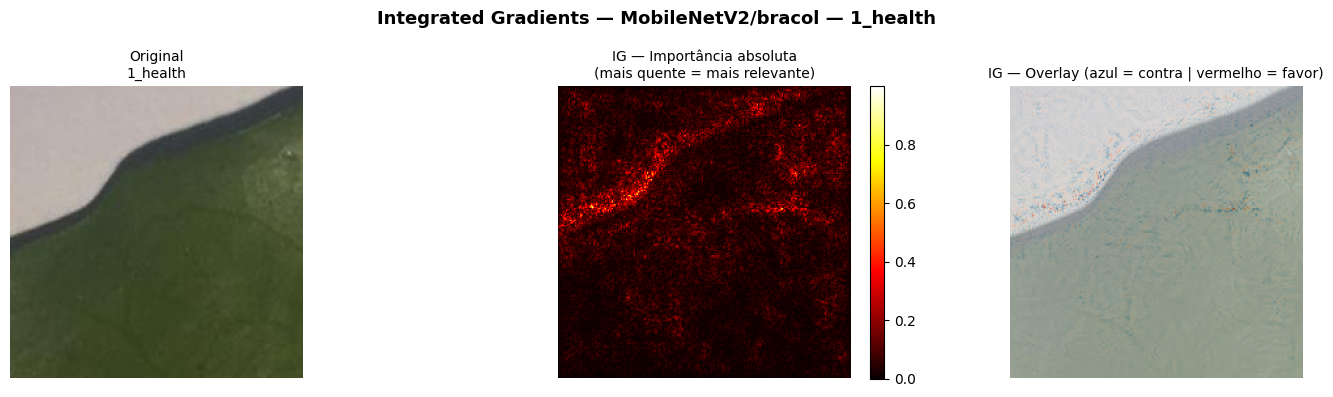

  [1_health] OK


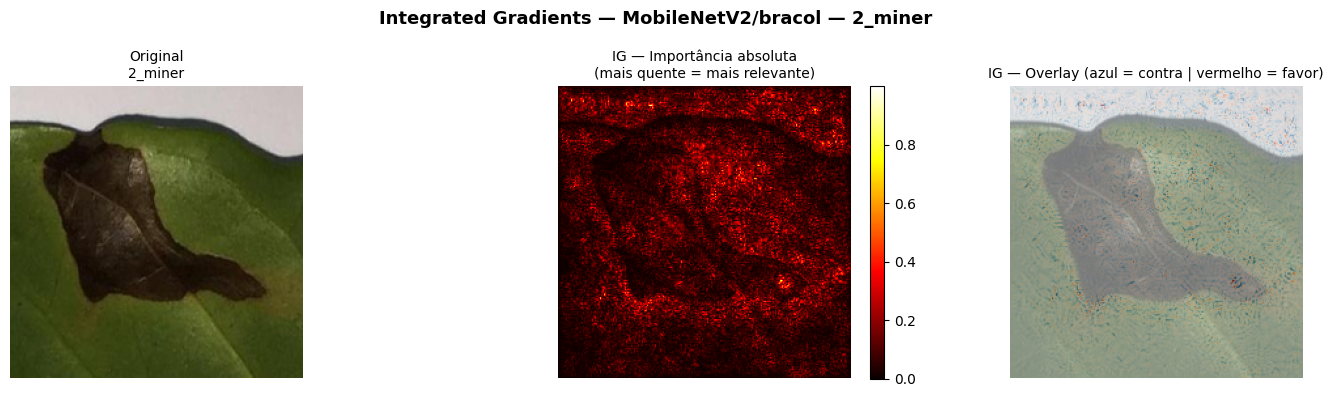

  [2_miner] OK


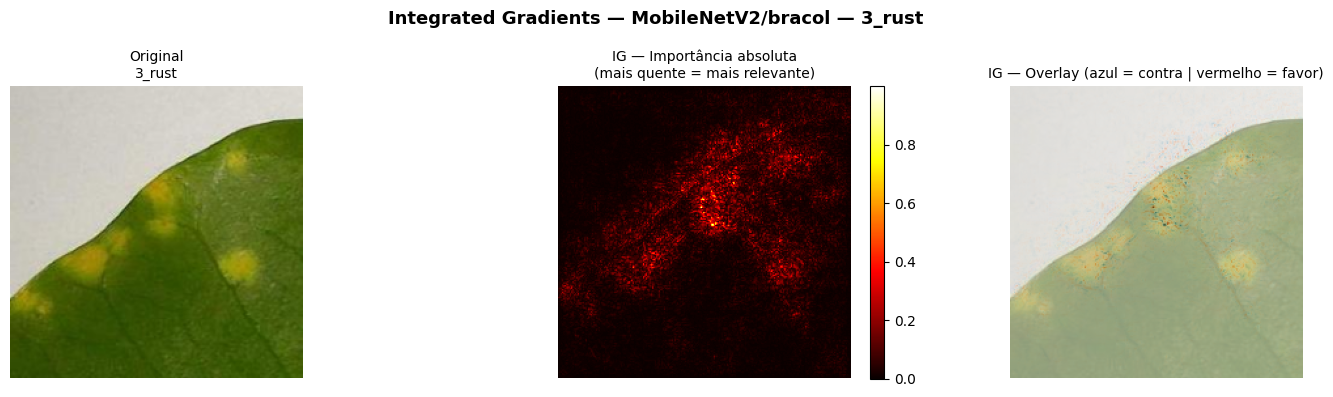

  [3_rust] OK


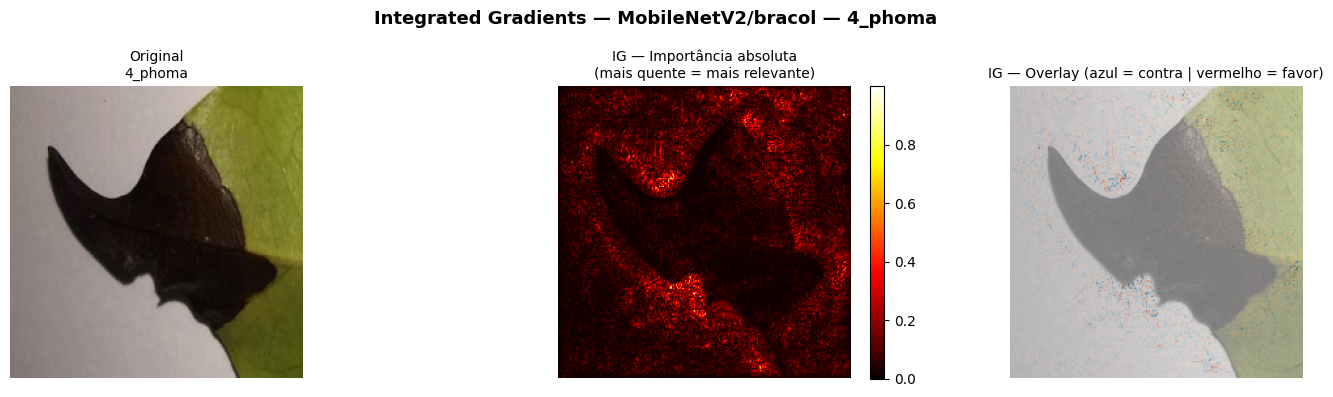

  [4_phoma] OK


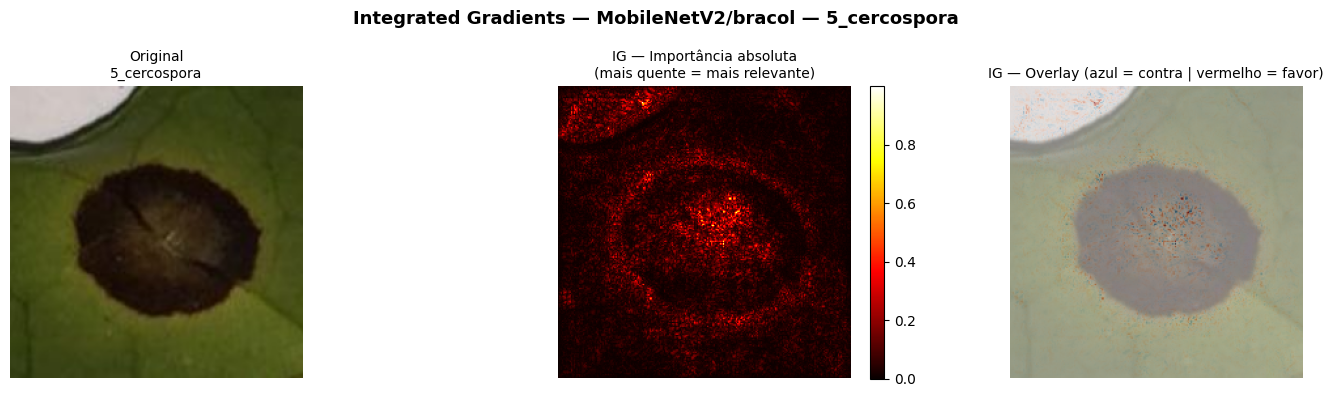

  [5_cercospora] OK


In [23]:

def integrated_gradients(model, img_array, class_idx, m_steps=50, batch_size=32):
    """
    Integrated Gradients (Sundararajan et al., 2017) — substituto ao SHAP GradientExplainer.
    Compatível com TF 2.16+ (não depende de tf.keras.backend.learning_phase).
    Baseline: imagem preta (zeros).
    """
    baseline = tf.zeros_like(img_array)                        # (1, 224, 224, 3)
    alphas   = tf.linspace(0.0, 1.0, m_steps + 1)             # m_steps+1 pontos

    # Interpola entre baseline e imagem de entrada
    interp = tf.concat(
        [baseline + a * (img_array - baseline) for a in alphas], axis=0
    )  # (m_steps+1, 224, 224, 3)

    # Calcula gradientes em mini-batches para evitar OOM
    all_grads = []
    for i in range(0, len(interp), batch_size):
        batch = tf.Variable(interp[i : i + batch_size])
        with tf.GradientTape() as tape:
            preds  = model(batch, training=False)
            target = preds[:, class_idx]
        all_grads.append(tape.gradient(target, batch))

    grads = tf.concat(all_grads, axis=0)                       # (m_steps+1, 224, 224, 3)

    # Integração pela regra do trapézio
    avg_grads = tf.reduce_mean((grads[:-1] + grads[1:]) / 2.0, axis=0, keepdims=True)

    # IG = (img − baseline) × gradiente médio
    ig = (img_array - baseline) * avg_grads
    return ig.numpy()[0]                                       # (224, 224, 3)


print("Gerando explicações por Integrated Gradients por classe...")
for class_idx, class_name in enumerate(class_names_geral):
    acertos = [d for d in all_test_info if d['true_label'] == class_idx and d['pred_label'] == class_idx]
    if not acertos:
        print(f"  [{class_name}] Sem acertos — pulando.")
        continue

    img_rgb, img_array = carregar_imagem(acertos[0]['path'])
    img_tensor = tf.constant(img_array, dtype=tf.float32)

    ig = integrated_gradients(model, img_tensor, class_idx)    # (224, 224, 3)

    # Mapa de importância absoluta (média dos canais RGB)
    ig_abs  = np.abs(ig).mean(axis=-1)                         # (224, 224)
    ig_norm = (ig_abs - ig_abs.min()) / (ig_abs.max() - ig_abs.min() + 1e-8)

    # Mapa de contribuição signed (positivo = favor, negativo = contra)
    ig_signed      = ig.mean(axis=-1)
    ig_signed_norm = (ig_signed - ig_signed.min()) / (ig_signed.max() - ig_signed.min() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original\n{class_name}', fontsize=10)
    axes[0].axis('off')

    im1 = axes[1].imshow(ig_norm, cmap='hot')
    axes[1].set_title('IG — Importância absoluta\n(mais quente = mais relevante)', fontsize=10)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    cmap_rdb = plt.colormaps.get_cmap('RdBu_r')
    ig_rgb   = cmap_rdb(ig_signed_norm)[:, :, :3]
    overlay  = ig_rgb * 0.5 + img_rgb.astype(np.float32) / 255 * 0.5
    axes[2].imshow(np.clip(overlay, 0, 1))
    axes[2].set_title('IG — Overlay (azul = contra | vermelho = favor)', fontsize=10)
    axes[2].axis('off')

    plt.suptitle(f'Integrated Gradients — {BACKBONE_ATIVO}/{DATASET_ATIVO} — {class_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'ig_{NOME_ARQUIVO}_{class_name}.png'), dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  [{class_name}] OK")


# Validação Multi-Seed (Rigor Estatístico)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd

# Seeds adicionais treinadas com os MESMOS best_params vindos do Optuna — o objetivo
# é medir a variância do desempenho final (inicialização de pesos + embaralhamento),
# não buscar novos hiperparâmetros. O modelo canônico (SEED=42, já treinado acima) é
# reaproveitado para TFLite/latência/Grad-CAM/LIME/IG — não é retreinado aqui.
SEEDS_ADICIONAIS = [123, 2024]

def treinar_com_seed(seed, best_params, backbone_name=BACKBONE_ATIVO):
    """Treina o modelo final com uma seed distinta e retorna as métricas no conjunto de teste."""
    np.random.seed(seed)
    tf.random.set_seed(seed)
    K.clear_session()

    m = create_model(trial=None, is_final=True, best_params=best_params, backbone_name=backbone_name)
    aug_layer_seed = get_augmentation_layer(best_params=best_params)
    train_dataset_seed = apply_augmentation(train_dataset, aug_layer_seed)

    early_stop_seed = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr_seed = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6)

    m.fit(
        train_dataset_seed,
        validation_data=val_dataset,
        epochs=100,
        callbacks=[early_stop_seed, reduce_lr_seed],
        verbose=0,
        class_weight=class_weights
    )

    y_true_seed = np.concatenate([y for x, y in test_dataset], axis=0)
    y_pred_probs_seed = m.predict(test_dataset, verbose=0)
    y_pred_seed = np.argmax(y_pred_probs_seed, axis=-1)

    metricas = {
        'seed':            seed,
        'accuracy':        accuracy_score(y_true_seed, y_pred_seed),
        'f1_macro':        f1_score(y_true_seed, y_pred_seed, average='macro'),
        'precision_macro': precision_score(y_true_seed, y_pred_seed, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true_seed, y_pred_seed, average='macro', zero_division=0),
    }

    del m, aug_layer_seed, train_dataset_seed
    K.clear_session()
    gc.collect()
    return metricas


# Reaproveita as métricas já calculadas para o modelo canônico (SEED=42) — não retreina
resultados_multiseed = [{
    'seed':            SEED,
    'accuracy':        test_acc,
    'f1_macro':        f1_score(y_true_test, y_pred_test, average='macro'),
    'precision_macro': precision_score(y_true_test, y_pred_test, average='macro', zero_division=0),
    'recall_macro':    recall_score(y_true_test, y_pred_test, average='macro', zero_division=0),
}]

for s in SEEDS_ADICIONAIS:
    print(f"Treinando com seed={s} ({BACKBONE_ATIVO} / {DATASET_ATIVO})...")
    resultados_multiseed.append(treinar_com_seed(s, best_params))
    print(f"  Concluído. Acurácia={resultados_multiseed[-1]['accuracy']:.4f} | F1-Macro={resultados_multiseed[-1]['f1_macro']:.4f}")

df_multiseed = pd.DataFrame(resultados_multiseed)
print("\n── Resultados por seed ──")
print(df_multiseed.to_string(index=False))

media_multiseed  = df_multiseed[['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']].mean()
desvio_multiseed = df_multiseed[['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']].std()

print(f"\n── Média ± Desvio-padrão ({len(df_multiseed)} seeds) ──")
for col in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
    print(f"  {col:17s}: {media_multiseed[col]:.4f} ± {desvio_multiseed[col]:.4f}")

# Persiste os valores BRUTOS por seed (não só a média/dp) — necessário para os testes de
# significância estatística pareados entre modelos, feitos mais adiante comparando as
# métricas seed a seed de diferentes combinações Modelo × Dataset.
df_multiseed_export = df_multiseed.copy()
df_multiseed_export.insert(0, 'dataset', DATASET_ATIVO)
df_multiseed_export.insert(0, 'modelo', BACKBONE_ATIVO)
multiseed_path = os.path.join(OUTPUT_DIR, f'multiseed_{NOME_ARQUIVO}.csv')
df_multiseed_export.to_csv(multiseed_path, index=False)
print(f"\nResultados por seed salvos em: {multiseed_path}")

Treinando com seed=123 (MobileNetV2 / bracol)...
  Concluído. Acurácia=0.9364 | F1-Macro=0.9267
Treinando com seed=2024 (MobileNetV2 / bracol)...
  Concluído. Acurácia=0.9315 | F1-Macro=0.9236

── Resultados por seed ──
 seed  accuracy  f1_macro  precision_macro  recall_macro
   42   0.95110  0.944089         0.945225      0.943514
  123   0.93643  0.926711         0.936214      0.922737
 2024   0.93154  0.923588         0.929269      0.918789

── Média ± Desvio-padrão (3 seeds) ──
  accuracy         : 0.9397 ± 0.0102
  f1_macro         : 0.9315 ± 0.0110
  precision_macro  : 0.9369 ± 0.0080
  recall_macro     : 0.9283 ± 0.0133

Resultados por seed salvos em: outputs/MobileNetV2_bracol/multiseed_MobileNetV2_bracol.csv


# Acumulação de Resultados para Tabela Comparativa

In [25]:
# Coleta métricas do experimento atual (agregadas em SEED + SEEDS_ADICIONAIS) e adiciona à lista comparativa
tflite_path    = os.path.join(OUTPUT_DIR, f'{NOME_ARQUIVO}.tflite')
tflite_size_mb = os.path.getsize(tflite_path) / (1024 ** 2) if os.path.exists(tflite_path) else None

resultados_comparativos.append({
    'Modelo':                    BACKBONE_ATIVO,
    'Dataset':                    DATASET_ATIVO,
    'Acurácia (méd)':             round(media_multiseed['accuracy'], 4),
    'Acurácia (dp)':              round(desvio_multiseed['accuracy'], 4),
    'F1-Macro (méd)':             round(media_multiseed['f1_macro'], 4),
    'F1-Macro (dp)':              round(desvio_multiseed['f1_macro'], 4),
    'Precision-Macro (méd)':      round(media_multiseed['precision_macro'], 4),
    'Recall-Macro (méd)':         round(media_multiseed['recall_macro'], 4),
    'N_seeds':                    len(df_multiseed),
    # Nomes de coluna neutros de framework (nao "Keras"/"TFLite" especificamente) para que
    # esta tabela seja concatenavel com resultados_comparativos_*.csv de outros notebooks
    # (ex.: transformers.ipynb, que roda em PyTorch e exporta .ptl em vez de .tflite).
    'Lat. Em Memória (ms)':       round(latencia_media, 2),
    'Lat. Exportado (ms)':        round(lat_tflite_media, 2),
    'Tamanho Exportado (MB)':     round(tflite_size_mb, 2) if tflite_size_mb else 'N/A',
    'Formato Exportado':          'TFLite',
})

print(f"Resultado de '{BACKBONE_ATIVO} × {DATASET_ATIVO}' registrado ({len(df_multiseed)} seeds). Total acumulado: {len(resultados_comparativos)}")

Resultado de 'MobileNetV2 × bracol' registrado (3 seeds). Total acumulado: 1


# Tabela Comparativa — Modelos × Datasets

In [26]:
import glob
import pandas as pd

# Descobre linhas-resumo de notebooks de OUTROS frameworks (ex.: transformers.ipynb/ViT,
# ou um futuro notebook de Random Forest), que gravam em outputs/{modelo}_{dataset}/
# resultados_comparativos_{modelo}_{dataset}.csv com os MESMOS nomes de coluna usados
# aqui — basta copiar a pasta outputs/{modelo}_{dataset}/ do outro notebook para cá.
arquivos_externos = sorted(glob.glob(os.path.join('outputs', '*', 'resultados_comparativos_*.csv')))
dfs_externos = [pd.read_csv(f) for f in arquivos_externos]

if resultados_comparativos or dfs_externos:
    partes = []
    if resultados_comparativos:
        partes.append(pd.DataFrame(resultados_comparativos))
    partes.extend(dfs_externos)

    df_comp = pd.concat(partes, ignore_index=True)
    df_comp = df_comp.sort_values('F1-Macro (méd)', ascending=False).reset_index(drop=True)

    print("=" * 75)
    print("  TABELA COMPARATIVA — Modelos × Datasets")
    print("=" * 75)
    if dfs_externos:
        nomes_externos = [os.path.basename(f) for f in arquivos_externos]
        print(f"  (inclui {len(dfs_externos)} combinação(ões) de outros frameworks: {nomes_externos})")
        print("=" * 75)
    print(df_comp.to_string(index=True))
    print("=" * 75)

    # Para adicionar outro experimento CNN/Keras: altere BACKBONE_ATIVO / DATASET_ATIVO na
    # célula de setup e re-execute todas as células de treinamento e avaliação. Para
    # incluir ViT (ou outro framework), basta copiar sua pasta outputs/{modelo}_{dataset}/
    # para cá — esta célula já a descobre sozinha.

    # Salva no diretório raiz de saída (não é por combinação — acumula todas as rodadas)
    comparativos_path = os.path.join('outputs', 'resultados_comparativos.csv')
    df_comp.to_csv(comparativos_path, index=False)
    print(f"Tabela salva em: {comparativos_path}")
else:
    print("Nenhum resultado registrado. Execute as células de treinamento e avaliação primeiro, "
          "ou copie a pasta outputs/{modelo}_{dataset}/ de outro notebook (ex.: ViT) para cá.")

  TABELA COMPARATIVA — Modelos × Datasets
        Modelo Dataset  Acurácia (méd)  Acurácia (dp)  F1-Macro (méd)  F1-Macro (dp)  Precision-Macro (méd)  Recall-Macro (méd)  N_seeds  Lat. Em Memória (ms)  Lat. Exportado (ms)  Tamanho Exportado (MB) Formato Exportado
0  MobileNetV2  bracol          0.9397         0.0102          0.9315          0.011                 0.9369              0.9283        3                128.09                 17.0                    4.39            TFLite
Tabela salva em: outputs/resultados_comparativos.csv


# Teste de Significância Estatística entre Modelos (F1-Macro pareado por seed)

In [27]:
import glob
import itertools
from scipy import stats

# Varre outputs/*/multiseed_*.csv — cada arquivo contém as métricas BRUTAS (uma linha por
# seed) de uma combinação Modelo × Dataset já treinada nesta ou em execuções anteriores do
# notebook. Isso permite comparar estatisticamente modelos treinados em sessões diferentes
# do Kaggle, sem precisar reexecutar tudo numa única sessão.
arquivos_multiseed = sorted(glob.glob(os.path.join('outputs', '*', 'multiseed_*.csv')))

if len(arquivos_multiseed) < 2:
    print(f"Encontrado(s) {len(arquivos_multiseed)} arquivo(s) multiseed em outputs/*/multiseed_*.csv.")
    print("São necessárias pelo menos 2 combinações Modelo × Dataset treinadas para comparar "
          "estatisticamente (ex.: MobileNetV2 e Random Forest no mesmo dataset).")
else:
    dfs = [pd.read_csv(f) for f in arquivos_multiseed]
    df_todos = pd.concat(dfs, ignore_index=True)
    df_todos['experimento'] = df_todos['modelo'] + ' / ' + df_todos['dataset']

    # Só é válido comparar experimentos com o MESMO conjunto de seeds e o MESMO dataset de
    # teste — caso contrário o pareamento por seed não faz sentido estatisticamente.
    grupos_por_dataset = df_todos.groupby('dataset')['experimento'].unique()

    registros_testes = []
    for dataset_nome, experimentos in grupos_por_dataset.items():
        if len(experimentos) < 2:
            continue
        for exp_a, exp_b in itertools.combinations(sorted(experimentos), 2):
            serie_a = df_todos[df_todos['experimento'] == exp_a].set_index('seed')['f1_macro']
            serie_b = df_todos[df_todos['experimento'] == exp_b].set_index('seed')['f1_macro']

            seeds_comuns = sorted(set(serie_a.index) & set(serie_b.index))
            if len(seeds_comuns) < 2:
                continue
            a = serie_a.loc[seeds_comuns].values
            b = serie_b.loc[seeds_comuns].values

            # Teste t pareado — indicativo com poucas seeds (n=3 é o padrão deste notebook);
            # tratar o p-valor como sinal direcional, não como prova estatística forte.
            t_stat, p_ttest = stats.ttest_rel(a, b)

            # Wilcoxon signed-rank exige n>=6 pares para produzir p-valor bilateral válido;
            # com poucas seeds o teste é reportado como indisponível em vez de enganoso.
            if len(seeds_comuns) >= 6:
                try:
                    w_stat, p_wilcoxon = stats.wilcoxon(a, b)
                except ValueError:
                    p_wilcoxon = np.nan
            else:
                p_wilcoxon = np.nan

            registros_testes.append({
                'dataset':           dataset_nome,
                'modelo_a':          exp_a,
                'modelo_b':          exp_b,
                'n_seeds':           len(seeds_comuns),
                'f1_macro_a (méd)':  round(a.mean(), 4),
                'f1_macro_b (méd)':  round(b.mean(), 4),
                'diferenca_media':   round(a.mean() - b.mean(), 4),
                'p_valor_ttest':     round(p_ttest, 4),
                'significativo_5%':  'Sim' if p_ttest < 0.05 else 'Não',
                'p_valor_wilcoxon':  round(p_wilcoxon, 4) if not np.isnan(p_wilcoxon) else 'N/A (n<6)',
            })

    if registros_testes:
        df_testes = pd.DataFrame(registros_testes)
        print("=" * 100)
        print("  TESTES DE SIGNIFICÂNCIA ESTATÍSTICA — F1-Macro pareado por seed (teste t pareado)")
        print("=" * 100)
        print(df_testes.to_string(index=False))
        print("=" * 100)
        print("\nAviso: com apenas 3 seeds por experimento (padrão deste notebook), o teste t "
              "pareado tem baixo poder estatístico — trate p<0.05 como indício, não como prova "
              "definitiva. Aumentar SEEDS_ADICIONAIS eleva a confiabilidade do teste.")

        testes_path = os.path.join('outputs', 'testes_significancia.csv')
        df_testes.to_csv(testes_path, index=False)
        print(f"\nResultados salvos em: {testes_path}")
    else:
        print("Nenhum par de experimentos compartilha dataset e seeds suficientes para comparação.")

Nenhum par de experimentos compartilha dataset e seeds suficientes para comparação.


# Automação da Avaliação Cruzada (Modelo × Dataset)

In [28]:
def executar_experimento_completo(backbone_name, dataset_name, n_trials=60, seeds_adicionais=None):
    """
    Executa o pipeline completo para UMA combinação Modelo × Dataset e reaproveita as
    funções já definidas acima (objective, create_model, get_augmentation_layer,
    apply_augmentation, treinar_com_seed) para não duplicar lógica.

    Ao final, as variáveis globais (model, history, test_acc, df_multiseed, etc.) ficam
    apontando para esta combinação — então as células manuais de Grad-CAM/LIME/IG/matriz
    de confusão continuam funcionando normalmente sobre o último experimento executado,
    caso o usuário queira inspecionar visualmente um resultado específico do loop.
    """
    global BACKBONE_ATIVO, DATASET_ATIVO, NOME_ARQUIVO, OUTPUT_DIR, N_CLASSES
    global train_dir, val_dir, test_dir, train_dataset, val_dataset, test_dataset
    global class_names_geral, class_weights
    global study, best_params, model, aug_layer_final, train_dataset_final, history
    global test_loss, test_acc, tflite_path
    global latencia_media, latencia_std, latencia_p95, lat_tflite_media, lat_tflite_p95
    global y_true_test, y_pred_probs_test, y_pred_test
    global resultados_multiseed, df_multiseed, media_multiseed, desvio_multiseed

    if seeds_adicionais is None:
        seeds_adicionais = SEEDS_ADICIONAIS

    # ── 1. Ativa a combinação ───────────────────────────────────────────────
    BACKBONE_ATIVO = backbone_name
    DATASET_ATIVO  = dataset_name
    NOME_ARQUIVO   = f"{BACKBONE_ATIVO}_{DATASET_ATIVO}"
    OUTPUT_DIR     = os.path.join('outputs', NOME_ARQUIVO)
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    N_CLASSES      = DATASETS[DATASET_ATIVO]['n_classes']

    print(f"\n{'=' * 80}\n  EXPERIMENTO: {BACKBONE_ATIVO} × {DATASET_ATIVO}\n{'=' * 80}")

    # ── 2. Carrega os dados do dataset ativo ────────────────────────────────
    if dataset_name == 'rocole':
        preparar_rocole()
    cfg_dataset = DATASETS[DATASET_ATIVO]
    train_dir, val_dir, test_dir = cfg_dataset['train'], cfg_dataset['val'], cfg_dataset['test']

    train_dataset = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=img_size, batch_size=batch_size, label_mode='int', seed=123
    )
    class_names_geral = train_dataset.class_names
    val_dataset = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=img_size, batch_size=batch_size, label_mode='int', shuffle=False
    )
    test_dataset = tf.keras.utils.image_dataset_from_directory(
        test_dir, image_size=img_size, batch_size=batch_size, label_mode='int', shuffle=False
    )
    train_dataset = train_dataset.prefetch(AUTOTUNE)
    val_dataset   = val_dataset.prefetch(AUTOTUNE)
    test_dataset  = test_dataset.prefetch(AUTOTUNE)

    labels_ativo = np.concatenate([y for x, y in train_dataset], axis=0)
    counts_ativo = Counter(labels_ativo)
    total_ativo  = sum(counts_ativo.values())
    class_weights = {c: total_ativo / (len(counts_ativo) * n) for c, n in counts_ativo.items()}
    print(f"Classes: {class_names_geral} | Pesos: {class_weights}")

    # ── 3. Busca de hiperparâmetros com Optuna (reaproveita objective()) ───
    pruner_local  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
    sampler_local = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction="maximize", pruner=pruner_local, sampler=sampler_local)
    study.optimize(objective, n_trials=n_trials, gc_after_trial=True)
    best_params = study.best_params
    print(f"Melhores parâmetros ({NOME_ARQUIVO}): {best_params}")

    joblib.dump(study, os.path.join(OUTPUT_DIR, f'optuna_study_{NOME_ARQUIVO}.pkl'))
    with open(os.path.join(OUTPUT_DIR, f'best_params_{NOME_ARQUIVO}.json'), 'w') as f:
        json.dump(best_params, f, indent=2)

    # ── 4. Treinamento definitivo ────────────────────────────────────────────
    model = create_model(trial=None, is_final=True, best_params=best_params, backbone_name=BACKBONE_ATIVO)
    aug_layer_final = get_augmentation_layer(best_params=best_params)
    train_dataset_final = apply_augmentation(train_dataset, aug_layer_final)

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr  = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6)

    history = model.fit(
        train_dataset_final, validation_data=val_dataset, epochs=100,
        callbacks=[early_stop, reduce_lr], verbose=0, class_weight=class_weights
    )
    model.save(os.path.join(OUTPUT_DIR, f'{NOME_ARQUIVO}.keras'))

    # ── 5. Avaliação no conjunto de teste ────────────────────────────────────
    test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
    y_true_test = np.concatenate([y for x, y in test_dataset], axis=0)
    y_pred_probs_test = model.predict(test_dataset, verbose=0)
    y_pred_test = np.argmax(y_pred_probs_test, axis=1)
    f1_macro_teste = f1_score(y_true_test, y_pred_test, average='macro')
    print(f"Teste — Acurácia: {test_acc:.4f} | F1-Macro: {f1_macro_teste:.4f}")

    # ── 6. Exportação TFLite + benchmark de latência ─────────────────────────
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_bytes = converter.convert()
    tflite_path = os.path.join(OUTPUT_DIR, f'{NOME_ARQUIVO}.tflite')
    with open(tflite_path, 'wb') as f:
        f.write(tflite_bytes)

    sample_img = next(iter(test_dataset))[0][:1]
    for _ in range(10):
        _ = model(sample_img, training=False)
    tempos = []
    for _ in range(100):
        t0 = time.perf_counter()
        _ = model(sample_img, training=False)
        tempos.append((time.perf_counter() - t0) * 1000)
    latencia_media, latencia_std = np.mean(tempos), np.std(tempos)
    latencia_p95 = np.percentile(tempos, 95)

    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    in_det = interpreter.get_input_details()
    img_tflite = sample_img.numpy().astype(np.float32)
    for _ in range(10):
        interpreter.set_tensor(in_det[0]['index'], img_tflite)
        interpreter.invoke()
    tempos_tflite = []
    for _ in range(100):
        t0 = time.perf_counter()
        interpreter.set_tensor(in_det[0]['index'], img_tflite)
        interpreter.invoke()
        tempos_tflite.append((time.perf_counter() - t0) * 1000)
    lat_tflite_media = np.mean(tempos_tflite)
    lat_tflite_p95   = np.percentile(tempos_tflite, 95)
    tflite_size_mb   = os.path.getsize(tflite_path) / (1024 ** 2)
    print(f"Latência — Keras: {latencia_media:.2f} ms | TFLite: {lat_tflite_media:.2f} ms | Tamanho TFLite: {tflite_size_mb:.2f} MB")

    # ── 7. Validação multi-seed (reaproveita treinar_com_seed) ──────────────
    resultados_multiseed = [{
        'seed':            SEED,
        'accuracy':        test_acc,
        'f1_macro':        f1_macro_teste,
        'precision_macro': precision_score(y_true_test, y_pred_test, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true_test, y_pred_test, average='macro', zero_division=0),
    }]
    for s in seeds_adicionais:
        resultados_multiseed.append(treinar_com_seed(s, best_params, backbone_name=BACKBONE_ATIVO))
        print(f"  seed={s} -> Acurácia={resultados_multiseed[-1]['accuracy']:.4f} | F1-Macro={resultados_multiseed[-1]['f1_macro']:.4f}")

    df_multiseed = pd.DataFrame(resultados_multiseed)
    media_multiseed  = df_multiseed[['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']].mean()
    desvio_multiseed = df_multiseed[['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']].std()

    df_multiseed_export = df_multiseed.copy()
    df_multiseed_export.insert(0, 'dataset', DATASET_ATIVO)
    df_multiseed_export.insert(0, 'modelo', BACKBONE_ATIVO)
    df_multiseed_export.to_csv(os.path.join(OUTPUT_DIR, f'multiseed_{NOME_ARQUIVO}.csv'), index=False)

    # ── 8. Acumula na tabela comparativa global ──────────────────────────────
    resultados_comparativos.append({
        'Modelo':                    BACKBONE_ATIVO,
        'Dataset':                    DATASET_ATIVO,
        'Acurácia (méd)':             round(media_multiseed['accuracy'], 4),
        'Acurácia (dp)':              round(desvio_multiseed['accuracy'], 4),
        'F1-Macro (méd)':             round(media_multiseed['f1_macro'], 4),
        'F1-Macro (dp)':              round(desvio_multiseed['f1_macro'], 4),
        'Precision-Macro (méd)':      round(media_multiseed['precision_macro'], 4),
        'Recall-Macro (méd)':         round(media_multiseed['recall_macro'], 4),
        'N_seeds':                    len(df_multiseed),
        # Mesmos nomes neutros usados na celula manual acima, para compatibilidade com
        # resultados_comparativos_*.csv de notebooks de outros frameworks (ex.: ViT/PyTorch).
        'Lat. Em Memória (ms)':       round(latencia_media, 2),
        'Lat. Exportado (ms)':        round(lat_tflite_media, 2),
        'Tamanho Exportado (MB)':     round(tflite_size_mb, 2),
        'Formato Exportado':          'TFLite',
    })

    K.clear_session()
    gc.collect()
    print(f"Concluído: {NOME_ARQUIVO}. Total acumulado na tabela comparativa: {len(resultados_comparativos)}")

In [ ]:
# ── Executa a matriz Dataset × Modelo automaticamente ───────────────────────
# ATENÇÃO -- ESCOPO: com BRACOL e RoCoLe reativados, BACKBONES × DATASETS agora dá até
# 5 × 3 = 15 combinações (era 5 × 1 = 5). Cada combinação roda uma busca Optuna completa +
# treino final + 2 seeds adicionais -- rodar as 15 numa única sessão do Kaggle facilmente
# estoura o limite de RAM do kernel ("Your notebook tried to allocate more memory than is
# available") e/ou passa de várias horas.
#
# RECOMENDADO: rode em ETAPAS, restringindo BACKBONES_PARA_RODAR / DATASETS_PARA_RODAR a um
# subconjunto pequeno por sessão (ex.: 1 dataset por vez), copie a pasta outputs/ para um
# lugar seguro (ou o Kaggle Dataset de saída) ao final de cada etapa, reinicie o kernel e
# continue com o próximo subconjunto. Os defaults abaixo já rodam TODAS as combinações --
# ajuste as duas listas se quiser restringir.
BACKBONES_PARA_RODAR = list(BACKBONES.keys())   # ex.: ['MobileNetV2'] para rodar só um backbone
DATASETS_PARA_RODAR  = list(DATASETS.keys())    # ex.: ['bracol'] para rodar só um dataset por vez

# Reduzido de 60 (usado na busca manual de um único backbone/dataset) para 30 como default
# mais seguro agora que o número de combinações triplicou -- suba de volta para 60 numa
# rodada final, depois que validar que cada combinação cabe na memória/tempo disponíveis.
N_TRIALS_BATCH = 30

combinacoes = [(b, d) for b in BACKBONES_PARA_RODAR for d in DATASETS_PARA_RODAR]
print(f"Avaliação cruzada: {len(combinacoes)} combinação(ões) a treinar — {combinacoes}")

for backbone_name, dataset_name in combinacoes:
    executar_experimento_completo(backbone_name, dataset_name, n_trials=N_TRIALS_BATCH)

print(f"\nAvaliação cruzada concluída: {len(resultados_comparativos)} combinações na tabela comparativa.")
print("Execute as células de 'Tabela Comparativa' e 'Teste de Significância Estatística' "
      "acima para ver os resultados consolidados de todas as combinações.")

Avaliação cruzada: 10 combinação(ões) a treinar — [('MobileNetV2', 'bracol'), ('MobileNetV2', 'rocole'), ('MobileNetV3Small', 'bracol'), ('MobileNetV3Small', 'rocole'), ('MobileNetV3Large', 'bracol'), ('MobileNetV3Large', 'rocole'), ('EfficientNetV2B0', 'bracol'), ('EfficientNetV2B0', 'rocole'), ('NASNetMobile', 'bracol'), ('NASNetMobile', 'rocole')]

  EXPERIMENTO: MobileNetV2 × bracol
Found 1905 files belonging to 5 classes.
Found 408 files belonging to 5 classes.
Found 409 files belonging to 5 classes.


[I 2026-09-01 05:47:29,994] A new study created in memory with name: no-name-ce0516a9-48a1-4810-ae84-f6b827719ba1


Classes: ['1_health', '2_miner', '3_rust', '4_phoma', '5_cercospora'] | Pesos: {2: 0.5489913544668588, 3: 1.0793201133144477, 4: 1.4377358490566037, 1: 0.9202898550724637, 0: 2.1284916201117317}


[I 2026-09-01 05:52:50,201] Trial 0 finished with value: 0.9322367153330365 and parameters: {'learning_rate': 5.6115164153345e-05, 'use_pretrained': True, 'fine_tune': True, 'optimizer': 'AdamW', 'n_dense_layers': 3, 'dense_units_l0': 128, 'dropout_rate_l0': 0.5879639408647976, 'dense_units_l1': 896, 'dropout_rate_l1': 0.28493564427131046, 'dense_units_l2': 256, 'dropout_rate_l2': 0.27336180394137355, 'fine_tune_at': 60, 'rotation': 0.052475643163223784, 'contrast': 0.08638900372842316, 'brightness': 0.058245828039608386, 'zoom_height': 0.02237057894447589, 'zoom_width': -0.07210122786959164, 'translate_height': 0.029214464853521818, 'translate_width': 0.03663618432936917}. Best is trial 0 with value: 0.9322367153330365.
[I 2026-09-01 05:56:48,601] Trial 1 finished with value: 0.9082107816388587 and parameters: {'learning_rate': 8.168455894760161e-05, 'use_pretrained': True, 'fine_tune': False, 'optimizer': 'RMSprop', 'n_dense_layers': 3, 'dense_units_l0': 1024, 'dropout_rate_l0': 0.52